# Boom model training — fines_frac onlyStripped-down version of the full pipeline, predicting only `fines_frac` (fraction of total ejecta mass from fragments < 40mm diameter).

In [6]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap
from scipy.special import expit, logit
from sklearn.linear_model import Ridge
from sklearn.metrics import f1_score, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

### Feature helpers

In [7]:
_LOG_SOURCES = {
    "pi_strength": "log_pi_strength",
    "coupling": "log_coupling",
    "porosity": "log_porosity",
    "shape_factor": "log_shape",
    "pi_threshold_fines": "log_pi_threshold_fines",
    "energy": "log_energy",
    "strength": "log_strength",
    "gravity": "log_gravity",
    "atmosphere": "log_atmosphere",
}
_EPS = 1e-6

_DERIVED_SOURCES = {
    "log_coupling_sq": ("log_coupling", lambda x: x ** 2),
    "log_porosity_sq": ("log_porosity", lambda x: x ** 2),
    "log_pi_threshold_fines_sq": ("log_pi_threshold_fines", lambda x: x ** 2),
    "log_shape_sq": ("log_shape", lambda x: x ** 2),
    "log_shape_cu": ("log_shape", lambda x: x ** 3),
    "log_pi_strength_sq": ("log_pi_strength", lambda x: x ** 2),
    "log_pi_strength_cu": ("log_pi_strength", lambda x: x ** 3),
    "log_energy_x_coupling": (("log_energy", "log_coupling"), lambda a, b: a * b),
    "log_strength_x_coupling": (("log_strength", "log_coupling"), lambda a, b: a * b),
    "log_atm_x_sin": (("log_atmosphere", "sin_angle"), lambda a, b: a * b),
}


def build_geometry(df: pd.DataFrame) -> pd.DataFrame:
    X = df.copy()
    X["L_char"] = (X["energy"] / (X["atmosphere"] * X["gravity"])) ** 0.25
    X["pi_strength"] = X["strength"] / (X["atmosphere"] * X["gravity"] * X["L_char"])
    X["sin_angle"] = np.sin(X["angle_rad"])
    X["cos_angle"] = np.cos(X["angle_rad"])
    X["D_fines"] = 40.0
    X["pi_threshold_fines"] = X["D_fines"] / X["L_char"]
    return X


class ZLogFeatureTransforms:
    def __init__(self):
        self._scalers: dict[str, StandardScaler] = {}
        self._derived_scalers: dict[str, StandardScaler] = {}

    def _raw_logs(self, geom: pd.DataFrame) -> pd.DataFrame:
        logs = pd.DataFrame(index=geom.index)
        for source, log_col in _LOG_SOURCES.items():
            logs[log_col] = np.log(geom[source].clip(lower=_EPS))
        return logs

    def _compute_derived(self, X: pd.DataFrame, logs: pd.DataFrame) -> dict[str, np.ndarray]:
        raw = {}
        for name, spec in _DERIVED_SOURCES.items():
            src, fn = spec
            if isinstance(src, tuple):
                a = logs[src[0]].to_numpy() if src[0] in logs.columns else X[src[0]].to_numpy()
                b = logs[src[1]].to_numpy() if src[1] in logs.columns else X[src[1]].to_numpy()
                raw[name] = fn(a, b)
            else:
                vals = logs[src].to_numpy() if src in logs.columns else X[src].to_numpy()
                raw[name] = fn(vals)
        return raw

    def fit(self, geom: pd.DataFrame) -> "ZLogFeatureTransforms":
        logs = self._raw_logs(geom)
        for log_col in logs:
            self._scalers[log_col] = StandardScaler().fit(logs[[log_col]].to_numpy())
        z_logs = pd.DataFrame(index=geom.index)
        for log_col in logs:
            z_logs[log_col] = self._scalers[log_col].transform(logs[[log_col]].to_numpy()).ravel()
        X_temp = geom.copy()
        X_temp["sin_angle"] = np.sin(geom["angle_rad"])
        X_temp["cos_angle"] = np.cos(geom["angle_rad"])
        for log_col in z_logs:
            X_temp[log_col] = z_logs[log_col]
        derived_raw = self._compute_derived(X_temp, z_logs)
        for name, vals in derived_raw.items():
            self._derived_scalers[name] = StandardScaler().fit(vals.reshape(-1, 1))
        return self

    def transform(self, geom: pd.DataFrame) -> pd.DataFrame:
        X = geom.copy()
        logs = self._raw_logs(geom)
        for log_col in logs:
            raw_log = logs[[log_col]].to_numpy()
            X[f"{log_col}_raw"] = raw_log.ravel()
            X[log_col] = self._scalers[log_col].transform(raw_log).ravel()
        X["sin_angle"] = np.sin(geom["angle_rad"])
        X["cos_angle"] = np.cos(geom["angle_rad"])
        z_logs = pd.DataFrame(index=geom.index)
        for log_col in logs:
            z_logs[log_col] = X[log_col]
        derived_raw = self._compute_derived(X, z_logs)
        for name, vals in derived_raw.items():
            X[name] = self._derived_scalers[name].transform(vals.reshape(-1, 1)).ravel()
        return X


def build_features(df: pd.DataFrame, z_log: ZLogFeatureTransforms) -> pd.DataFrame:
    return z_log.transform(build_geometry(df))


def transform_target_fines_frac(y: pd.DataFrame) -> pd.Series:
    return logit(y["fines_frac"].clip(_EPS, 1 - _EPS))


def invert_target_fines_frac(logit_fines_frac: pd.Series) -> pd.Series:
    return expit(logit_fines_frac)

### Model helpers

In [8]:
LINEAR_FEATURES = [
    "log_pi_strength",
    "log_pi_strength_sq",
    "log_pi_strength_cu",
    "log_coupling",
    "log_coupling_sq",
    "log_porosity",
    "log_porosity_sq",
    "log_shape",
    "log_shape_sq",
    "log_shape_cu",
    "log_pi_threshold_fines",
    "log_pi_threshold_fines_sq",
    "log_energy",
    "log_strength",
    "log_gravity",
    "log_atmosphere",
    "sin_angle",
    "cos_angle",
    "log_energy_x_coupling",
    "log_strength_x_coupling",
    "log_atm_x_sin",
]

LGB_FEATURES = list(LINEAR_FEATURES)

TARGET = "logit_fines_frac"


class HybridPhysicsModel:
    def __init__(self, linear_features, lgb_features, lgb_params=None, ridge_alpha=1.0):
        self.linear_features = linear_features
        self.lgb_features = lgb_features
        self.ridge_alpha = ridge_alpha
        self.lgb_params = lgb_params or {
            "n_estimators": 500,
            "learning_rate": 0.05,
            "num_leaves": 31,
            "min_child_samples": 10,
            "reg_alpha": 0.1,
            "reg_lambda": 0.1,
            "verbose": -1,
        }
        self.baseline = None
        self.residual = None
        self.best_iteration_ = None

    def fit(self, X, y, eval_set=None, eval_names=None, eval_metric="l2", callbacks=None):
        self.baseline = Ridge(alpha=self.ridge_alpha).fit(X[self.linear_features], y)
        residuals = y - self.baseline.predict(X[self.linear_features])
        residual_eval_set = None
        if eval_set is not None:
            residual_eval_set = []
            for X_eval, y_eval in eval_set:
                residual_eval_set.append((
                    X_eval[self.lgb_features],
                    y_eval - self.baseline.predict(X_eval[self.linear_features]),
                ))
        self.residual = lgb.LGBMRegressor(**self.lgb_params).fit(
            X[self.lgb_features],
            residuals,
            eval_set=residual_eval_set,
            eval_names=eval_names,
            eval_metric=eval_metric,
            callbacks=callbacks,
        )
        self.best_iteration_ = getattr(self.residual, "best_iteration_", None)
        return self

    def predict(self, X):
        num_iteration = self.best_iteration_ if self.best_iteration_ else None
        return (
            self.baseline.predict(X[self.linear_features])
            + self.residual.predict(X[self.lgb_features], num_iteration=num_iteration)
        )

    def baseline_coefficients(self):
        return pd.Series(self.baseline.coef_, index=self.linear_features)

### Configuration

In [9]:
data_dir = "forward_prediction"
n_splits = 5
seed = 42

### Load raw training data

In [10]:
X_raw = pd.read_csv(f"{data_dir}/train.csv").reset_index(drop=True)
y_raw = pd.read_csv(f"{data_dir}/train_labels.csv").reset_index(drop=True)
if len(X_raw) != len(y_raw):
    raise ValueError(
        f"{data_dir}/train.csv ({len(X_raw)} rows) and "
        f"{data_dir}/train_labels.csv ({len(y_raw)} rows) must align"
    )

### Feature engineering and transformed target

In [11]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

geom = build_geometry(X_raw)
z_log = ZLogFeatureTransforms().fit(geom)
X = build_features(X_raw, z_log)
y = transform_target_fines_frac(y_raw)

X

,porosity,atmosphere,gravity,coupling,strength,shape_factor,energy,angle_rad,L_char,pi_strength,sin_angle,cos_angle,D_fines,pi_threshold_fines,log_pi_strength_raw,log_pi_strength,log_coupling_raw,log_coupling,log_porosity_raw,log_porosity,log_shape_raw,log_shape,log_pi_threshold_fines_raw,log_pi_threshold_fines,log_energy_raw,log_energy,log_strength_raw,log_strength,log_gravity_raw,log_gravity,log_atmosphere_raw,log_atmosphere,log_coupling_sq,log_porosity_sq,log_pi_threshold_fines_sq,log_shape_sq,log_shape_cu,log_pi_strength_sq,log_pi_strength_cu,log_energy_x_coupling,log_strength_x_coupling,log_atm_x_sin
0,0.337215,0.781263,3.71,0.861258,1.305809,0.784028,3.826405,0.818303,1.071902,0.420294,0.729987,0.683461,40.0,37.316860,-0.866800,-1.240799,-0.149361,0.479957,-1.087034,0.973482,-0.243311,-1.630690,3.619445,0.840719,1.341926,1.066967,0.266823,-1.513414,1.311032,-0.043754,-0.246843,1.262984,-0.601899,-0.027973,-0.261330,1.219774,-1.574311,0.556026,-0.826086,0.214870,-0.352529,1.340633
1,0.058029,0.136205,1.62,0.561245,3.494501,0.922737,2.828754,1.193036,1.892220,8.369596,0.929493,0.368839,40.0,21.139196,2.124606,1.304011,-0.577597,-0.813921,-2.846804,-0.315970,-0.080411,-0.417376,3.051129,-1.234807,1.039836,-0.962182,1.251190,0.932442,0.482426,-1.177343,-1.993592,-0.721571,-0.263968,-0.481158,0.467725,-0.607110,-0.248886,0.721792,1.062212,0.465251,-0.388055,-0.685284
2,0.315632,0.774704,3.71,0.948860,1.366386,0.954922,3.068907,0.605872,1.016526,0.467676,0.569479,0.822006,40.0,39.349703,-0.759979,-1.149925,-0.052494,0.772632,-1.153180,0.925015,-0.046125,-0.162012,3.672488,1.034436,1.121321,-0.414843,0.312169,-1.400741,1.311032,-0.043754,-0.255275,1.253405,-0.315197,-0.077157,0.062445,-0.715883,-0.227605,0.332151,-0.647795,-0.554279,-0.740820,1.075827
3,0.033062,0.144204,1.62,0.713705,3.599419,0.932911,2.700574,1.073708,1.843915,8.356010,0.878975,0.476868,40.0,21.692975,2.122981,1.302629,-0.337286,-0.087841,-3.409364,-0.728180,-0.069446,-0.335707,3.076988,-1.140367,0.993464,-1.273666,1.280772,1.005944,0.482426,-1.177343,-1.936526,-0.656736,-0.776017,-0.251095,0.267788,-0.652326,-0.238045,0.718079,1.058990,-0.154840,0.343579,-0.566424
4,0.278207,0.414620,9.81,1.237205,1.996742,1.260855,3.484022,0.863568,0.962034,0.510284,0.760166,0.649729,40.0,41.578583,-0.672788,-1.075751,0.212854,1.574360,-1.279390,0.832536,0.231790,1.907955,3.727585,1.235653,1.248187,0.437321,0.691517,-0.458178,2.283402,1.286514,-0.880392,0.543183,1.156348,-0.164037,0.469587,1.941091,1.932900,0.162032,-0.521682,0.377826,-0.347034,0.693098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,0.063837,0.186159,3.71,0.690423,3.137082,0.901161,2.743598,1.286277,1.411776,3.217382,0.959797,0.280696,40.0,28.333111,1.168568,0.490703,-0.370451,-0.188047,-2.751417,-0.246076,-0.104071,-0.593605,3.344031,-0.165110,1.009270,-1.167497,1.143293,0.664350,1.311032,-0.043754,-1.681155,-0.366598,-0.754397,-0.502156,-0.867031,-0.476127,-0.291307,-0.782348,0.101874,-0.055383,0.303683,-0.279714
2926,0.299258,0.425989,9.81,0.491482,1.209891,0.868630,3.629967,0.638878,0.965403,0.299896,0.596295,0.802765,40.0,41.433454,-1.204320,-1.527929,-0.710330,-1.214961,-1.206450,0.885981,-0.140838,-0.867449,3.724089,1.222883,1.289224,0.712964,0.190531,-1.702976,2.283402,1.286514,-0.853342,0.573915,0.372358,-0.114942,0.441603,-0.181981,-0.429199,1.375241,-1.583995,-1.058383,2.697445,0.603183
2927,0.264179,0.446155,1.62,0.650748,1.377509,0.979404,3.517622,0.705479,1.485293,1.283163,0.648399,0.761301,40.0,26.930709,0.249328,-0.291300,-0.429633,-0.366860,-1.331129,0.794624,-0.020812,0.026529,3.293267,-0.350503,1.257785,0.501792,0.320277,-1.380596,0.482426,-1.177343,-0.807090,0.626464,-0.676798,-0.197011,-0.781828,-0.734663,-0.226277,-0.943034,0.036513,-0.428245,0.992594,0.684563
2928,0.078473,0.143900,3.71,0.719509,3.546015,0.970048,2.995128,1.218927,1.539024,4.315796,0.938730

In [12]:
y

0      -1.484636
1      -7.381744
2      -2.581431
3      -6.880776
4      -2.777066
          ...   
2925   -6.405178
2926   -2.882806
2927   -2.741146
2928   -6.427631
2929   -3.542449
Name: fines_frac, Length: 2930, dtype: float64

### Cross-validation setup

In [13]:
kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
cv_rmse = []
cv_mape = []
cv_r2 = []
cv_f1 = []
convergence_history = {}
shap_history = {}
best_iterations = []
early_stopping_rounds = 30
plot_shap_dependence = True

### CV loop: train, validate, log convergence, and early stop


=== Fold 0 / logit_fines_frac convergence ===
Training until validation scores don't improve for 30 rounds
[10]	valid_residual's l2: 0.0527031	train_residual's l2: 0.0489248
[20]	valid_residual's l2: 0.0528104	train_residual's l2: 0.0449563
[30]	valid_residual's l2: 0.0531142	train_residual's l2: 0.0414355
Early stopping, best iteration is:
[4]	valid_residual's l2: 0.0525426	train_residual's l2: 0.0519277
Evaluated only: l2
Fold 0: valid_l2 start=0.0526348, end=0.0530982, best=0.0525426 at iter 4


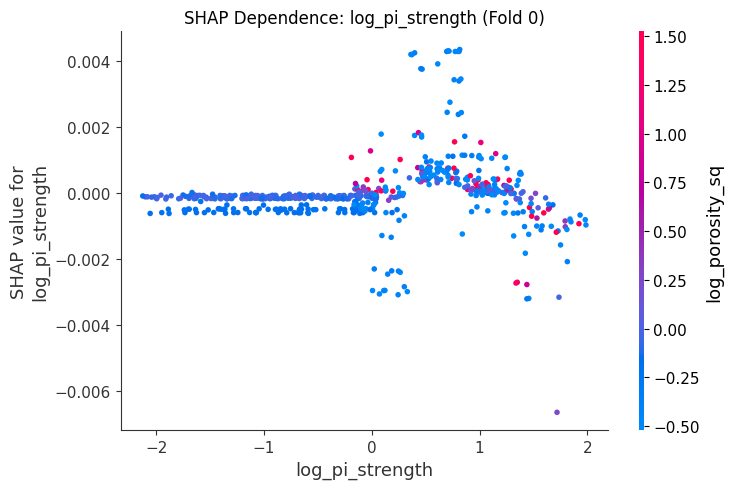

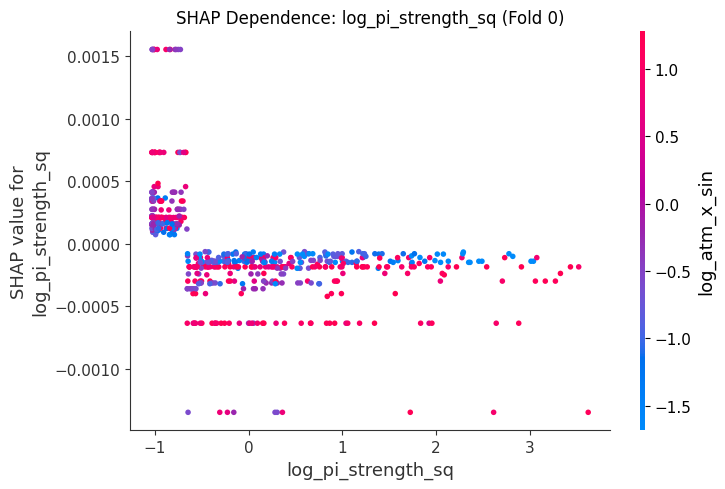

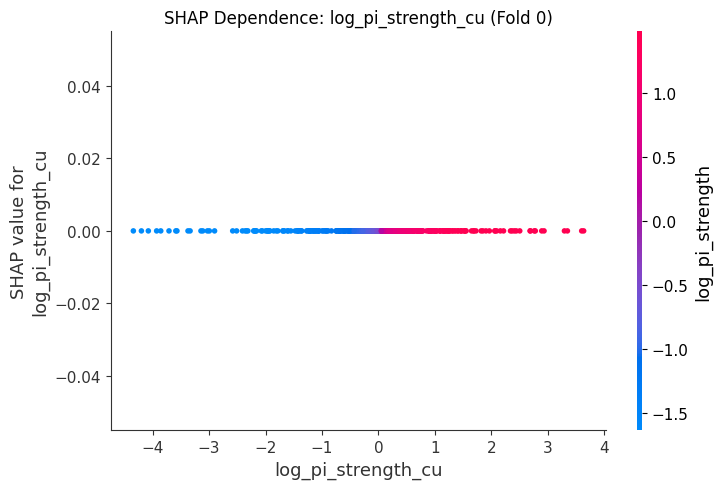

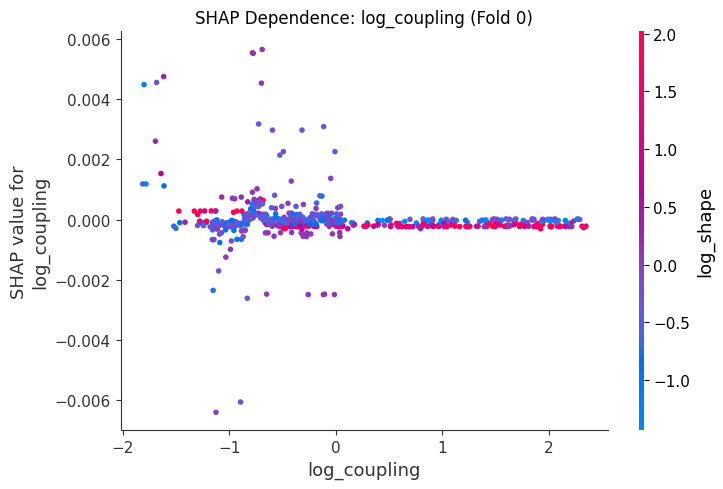

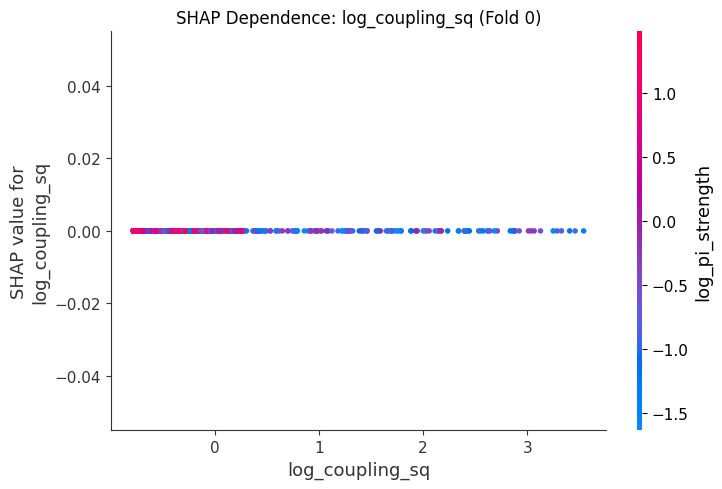

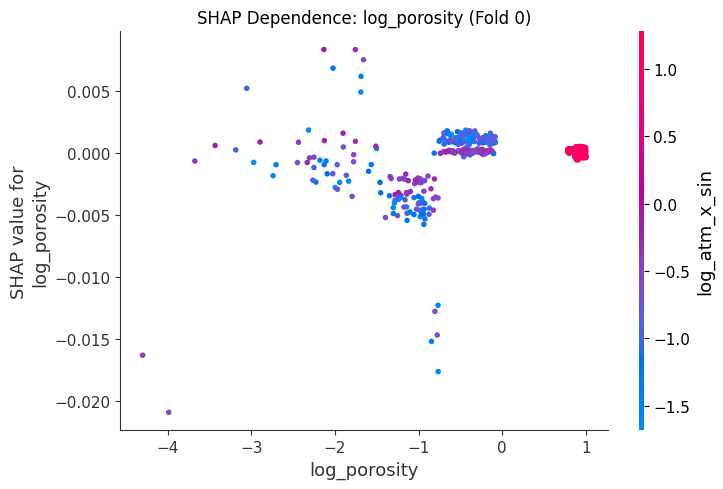

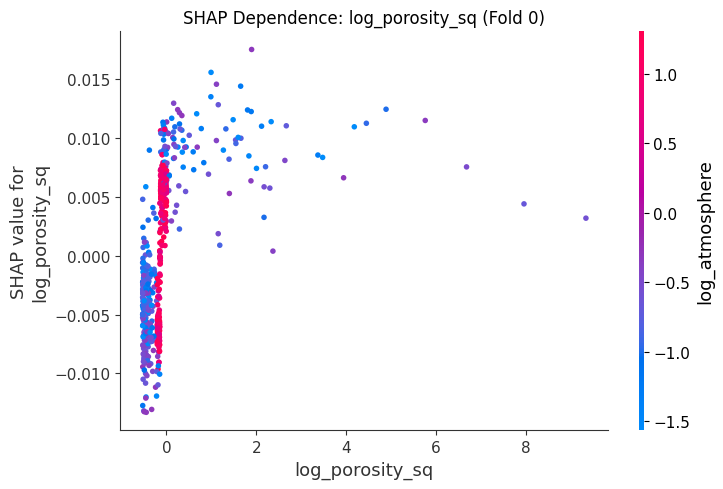

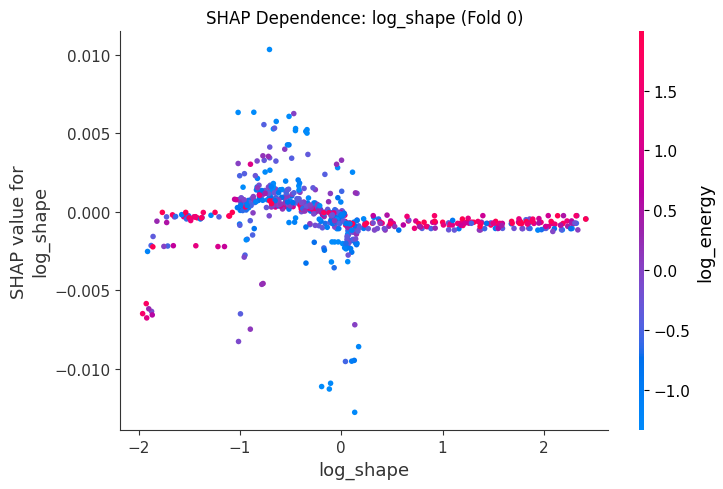

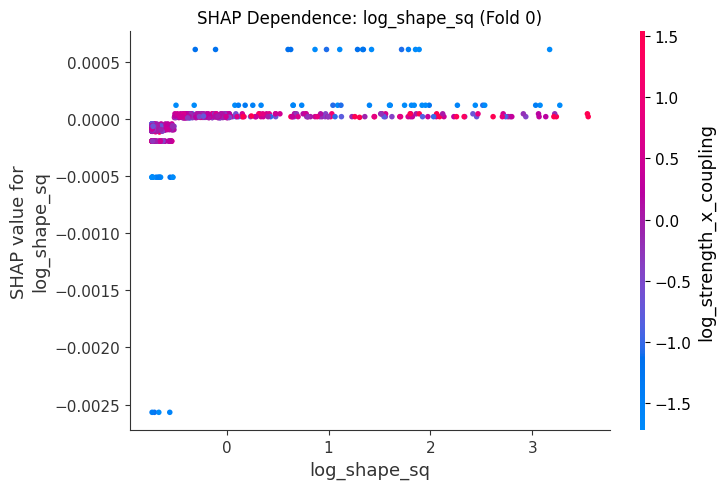

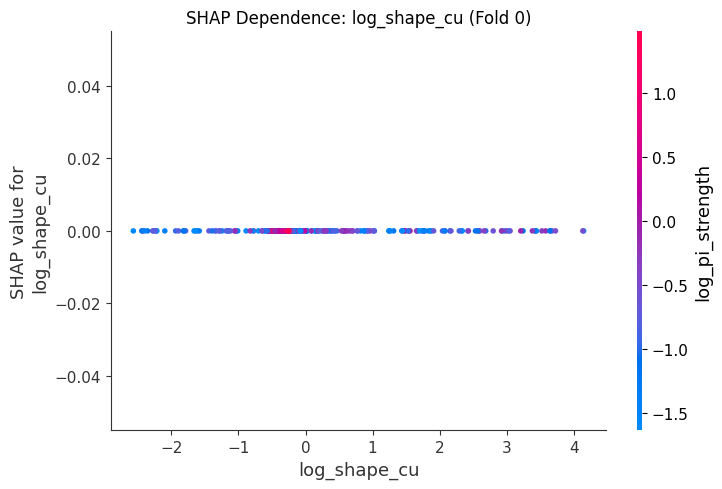

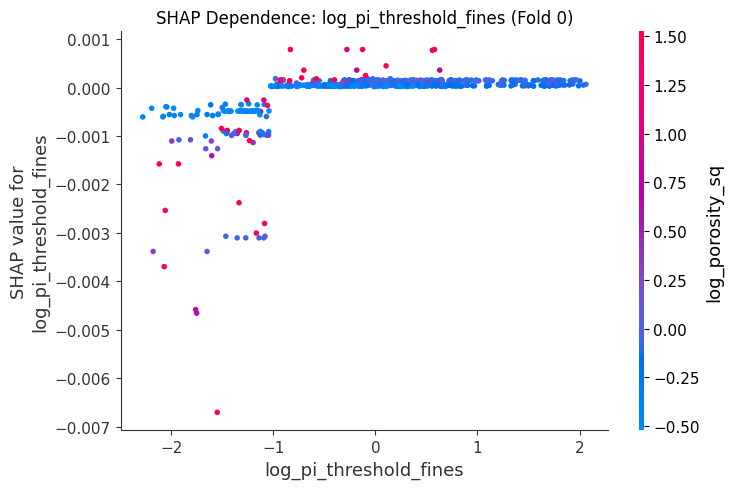

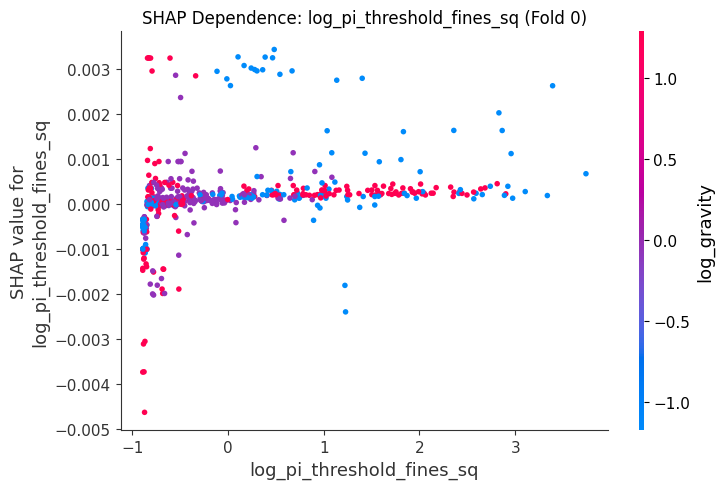

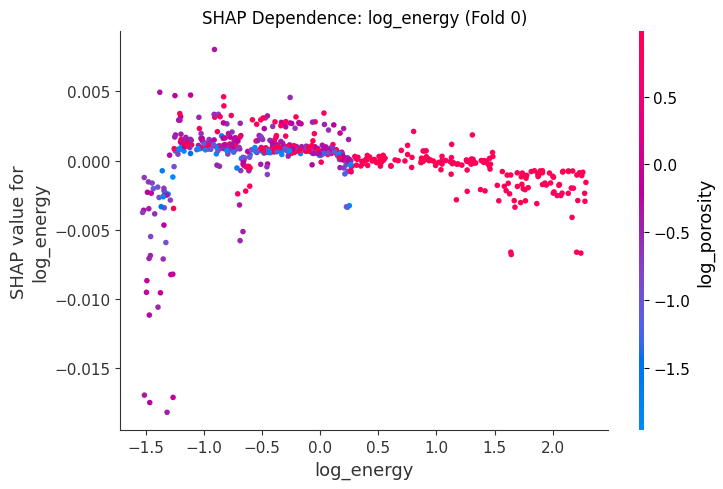

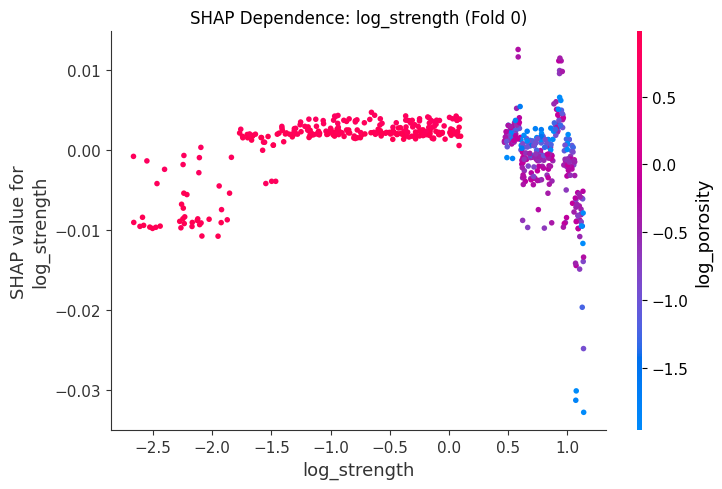

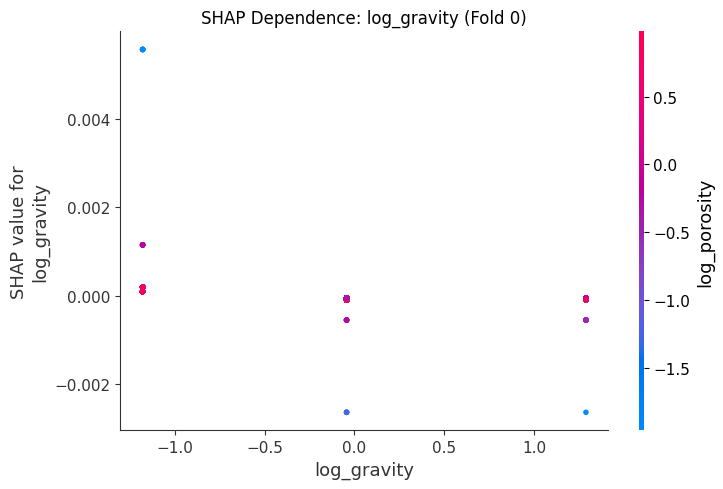

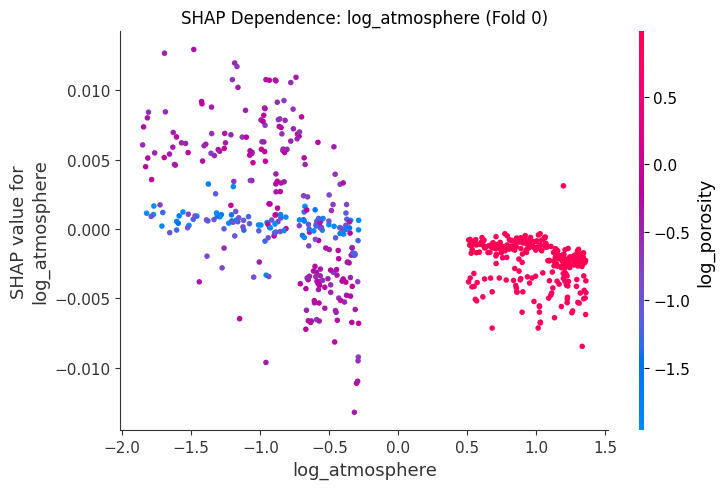

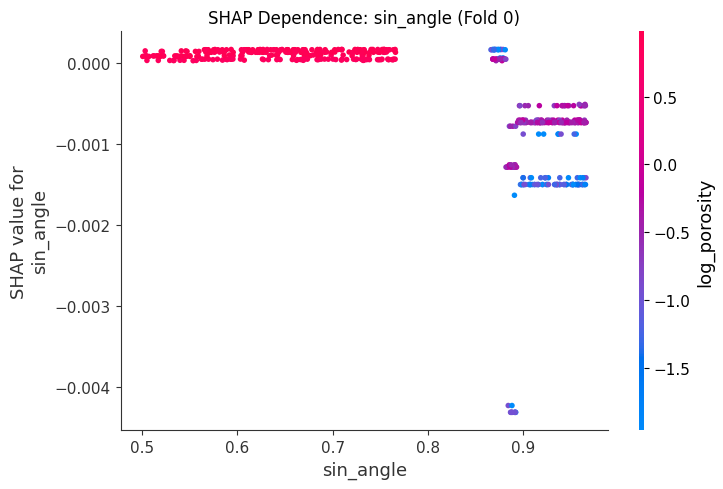

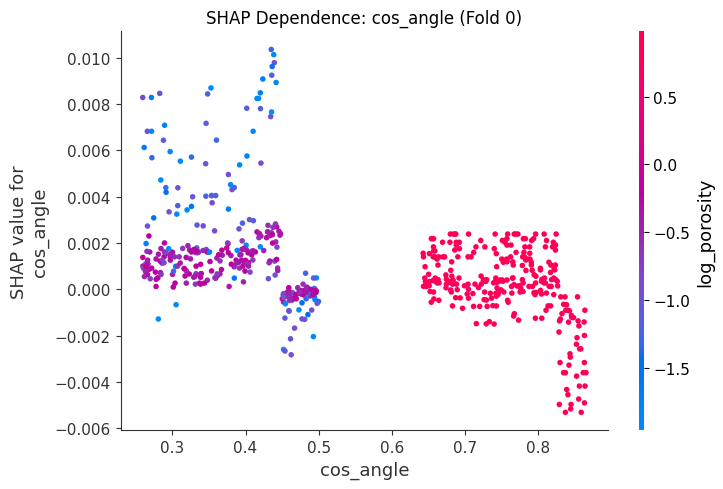

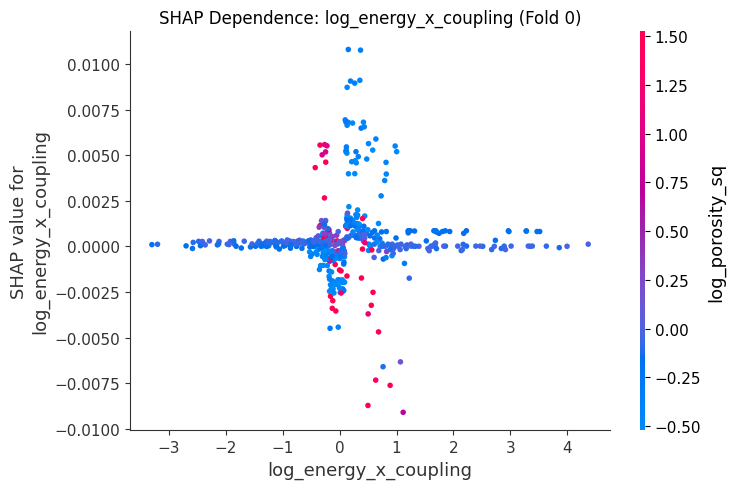

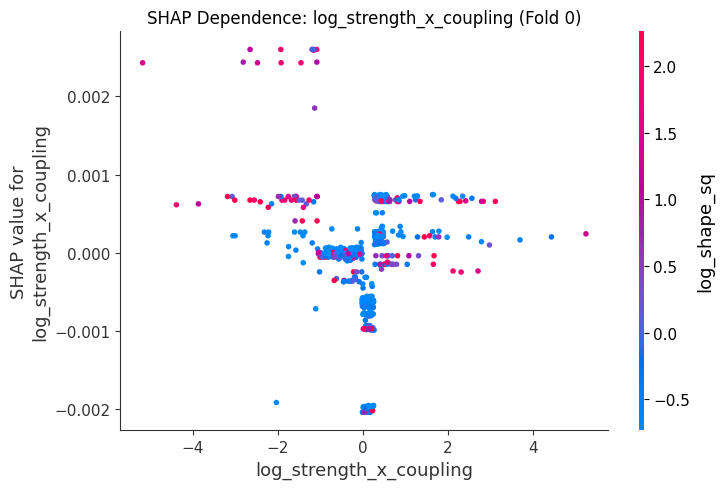

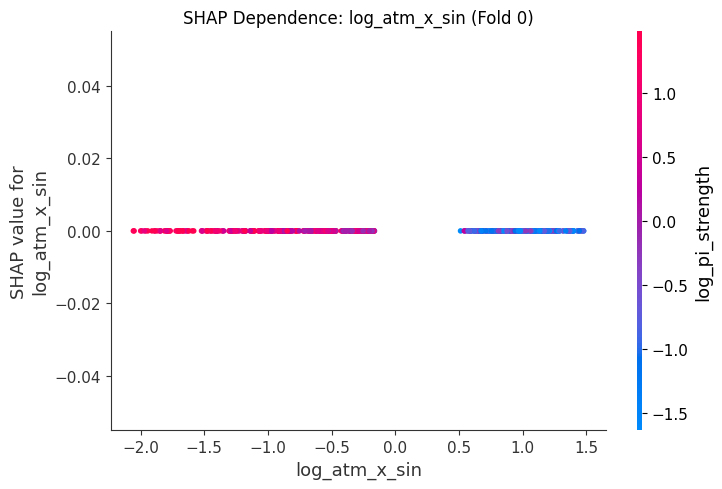

Fold 0 — RMSE=0.0149, MAPE=17.68%, R²=0.9562, F1=0.9734

=== Fold 1 / logit_fines_frac convergence ===
Training until validation scores don't improve for 30 rounds
[10]	valid_residual's l2: 0.0567835	train_residual's l2: 0.048405
[20]	valid_residual's l2: 0.0569071	train_residual's l2: 0.0445505
[30]	valid_residual's l2: 0.0568213	train_residual's l2: 0.0412644
Early stopping, best iteration is:
[9]	valid_residual's l2: 0.0567046	train_residual's l2: 0.048851
Evaluated only: l2
Fold 1: valid_l2 start=0.0568563, end=0.0572685, best=0.0567046 at iter 9


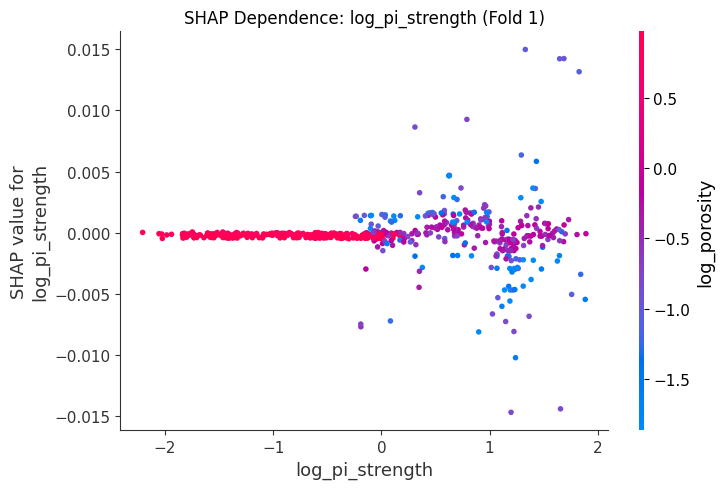

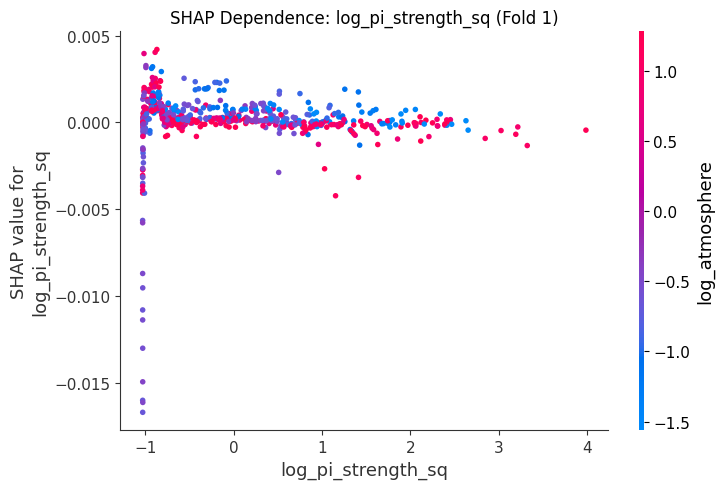

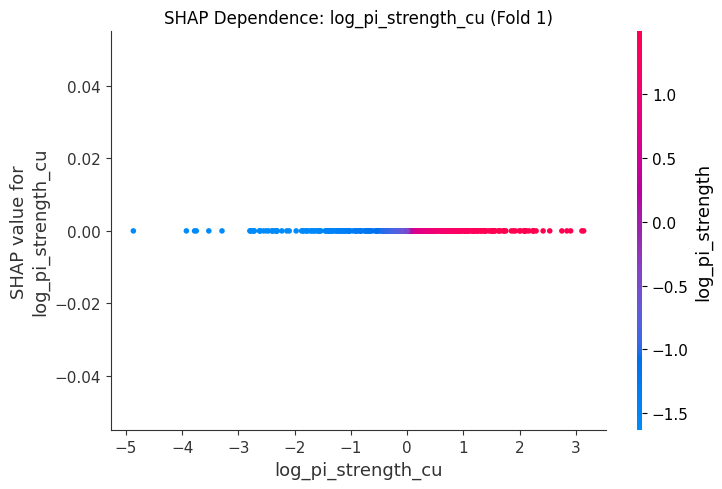

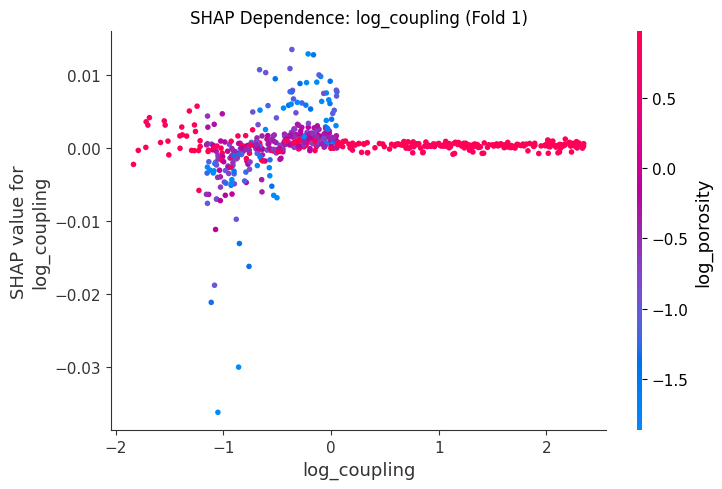

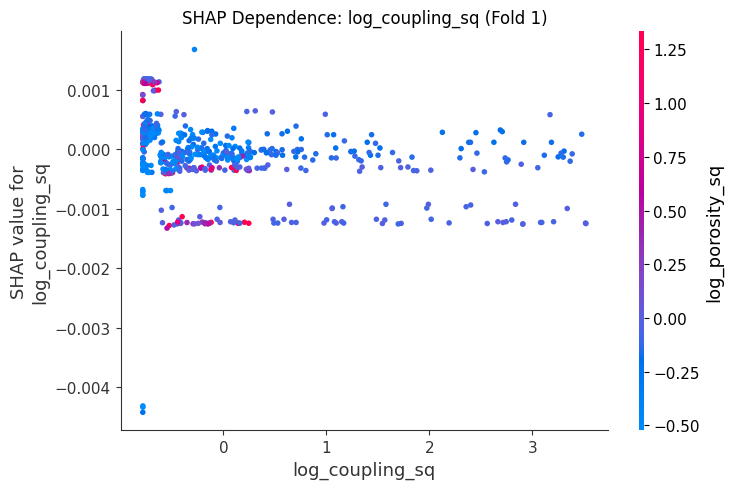

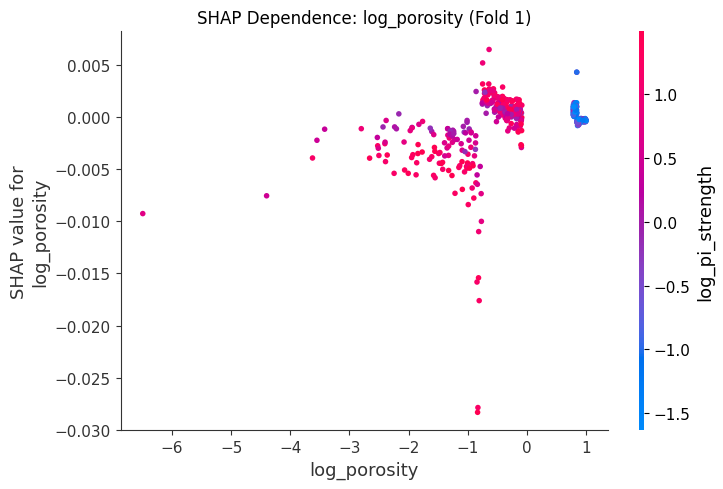

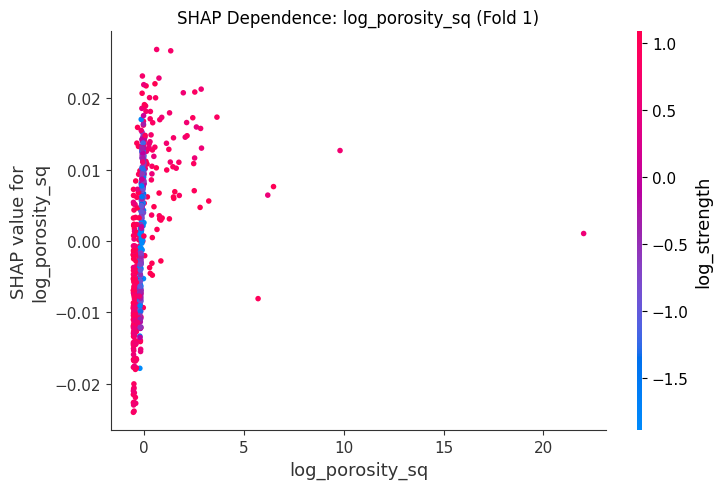

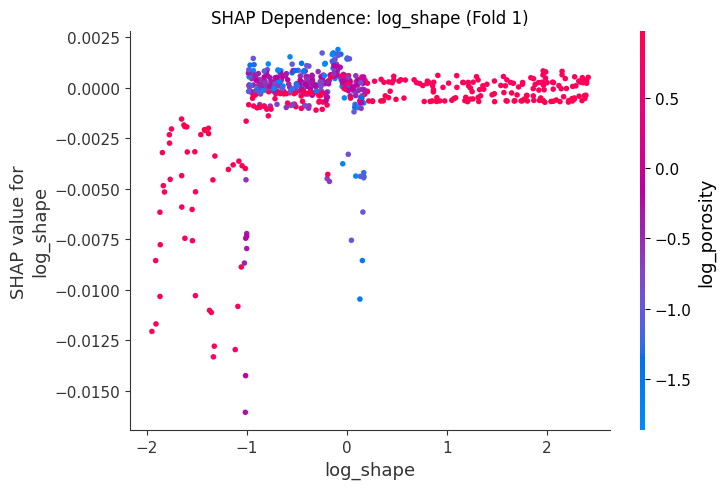

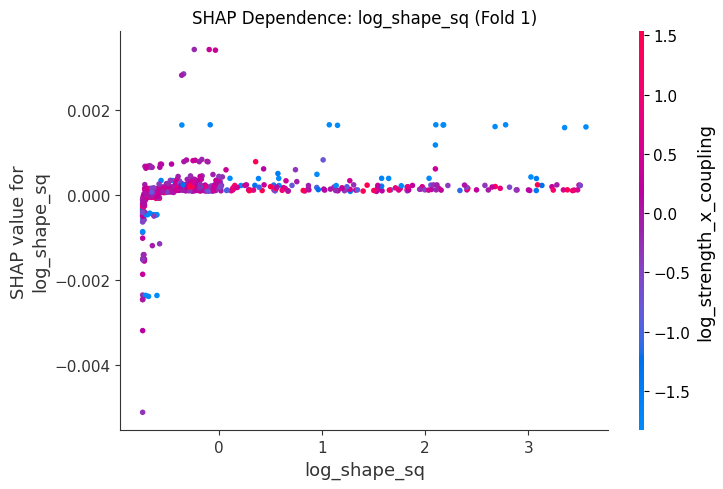

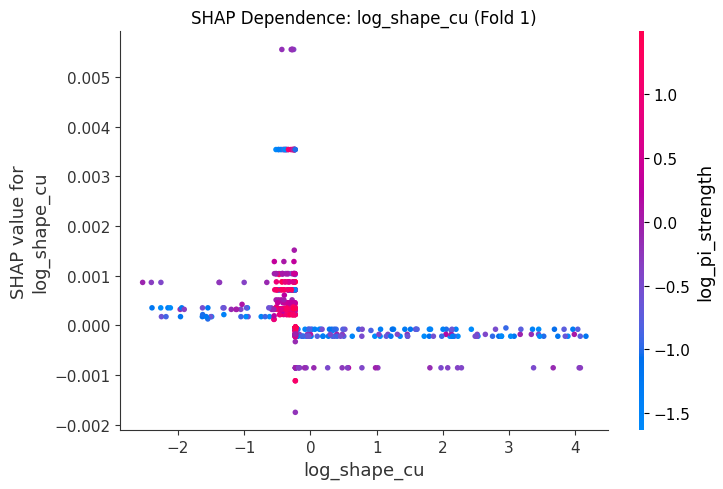

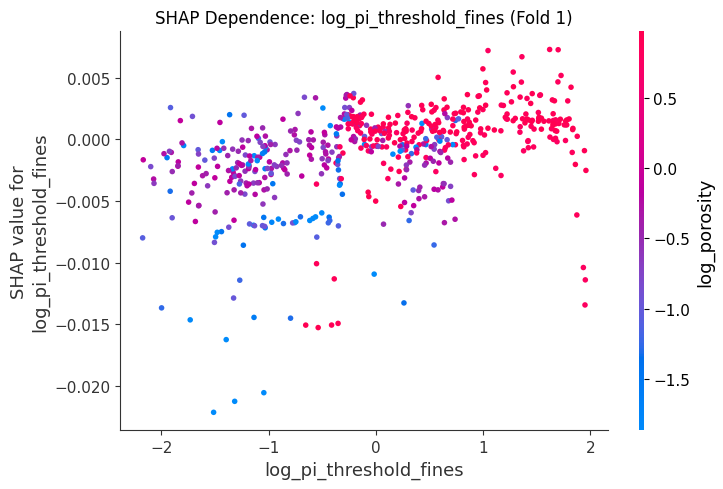

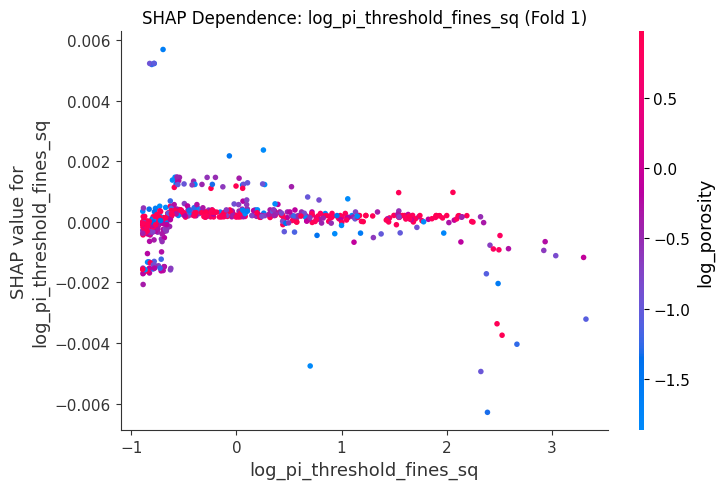

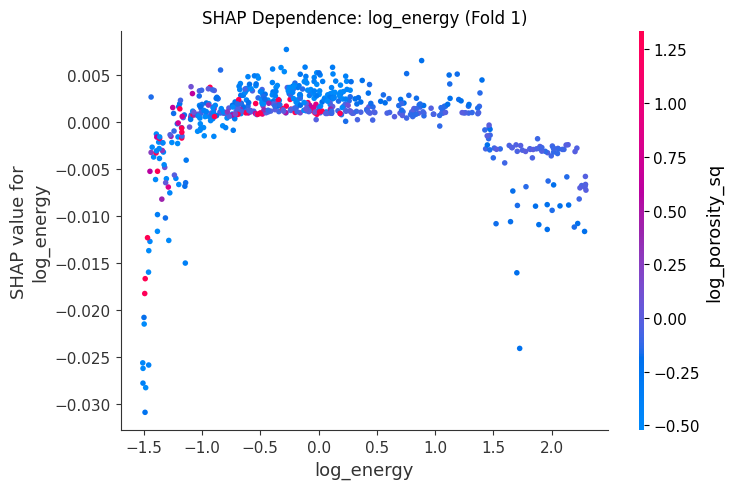

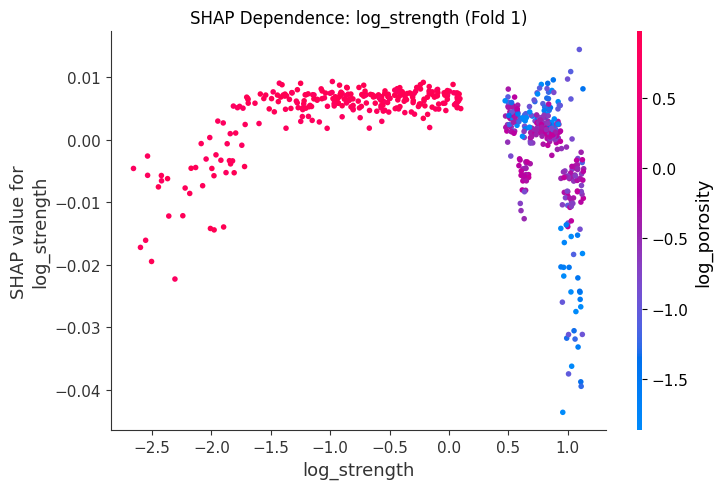

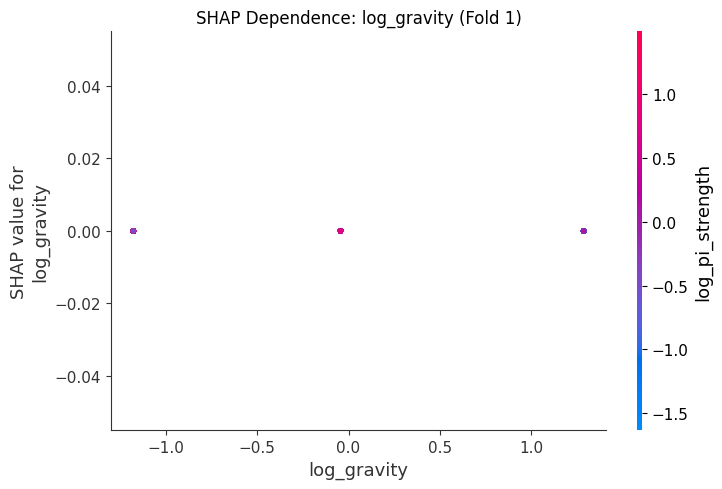

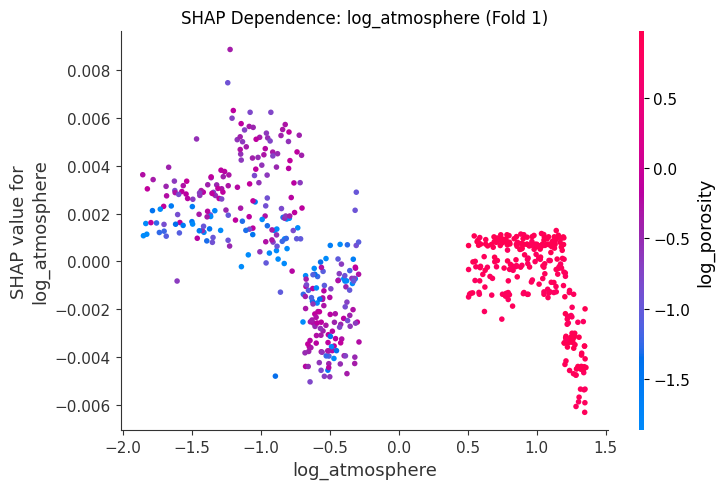

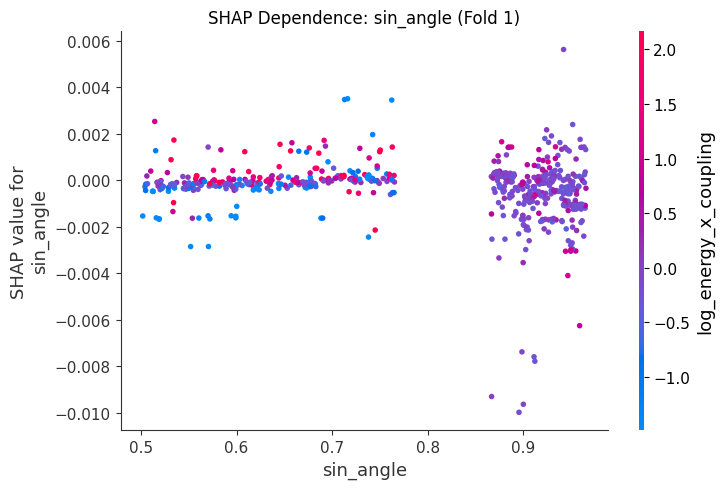

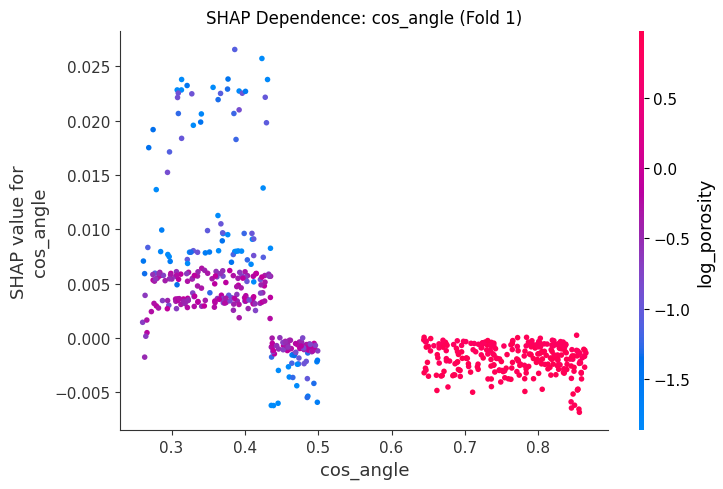

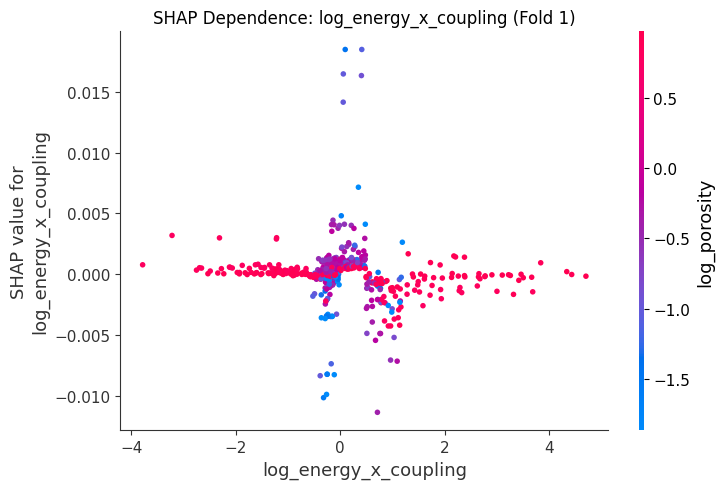

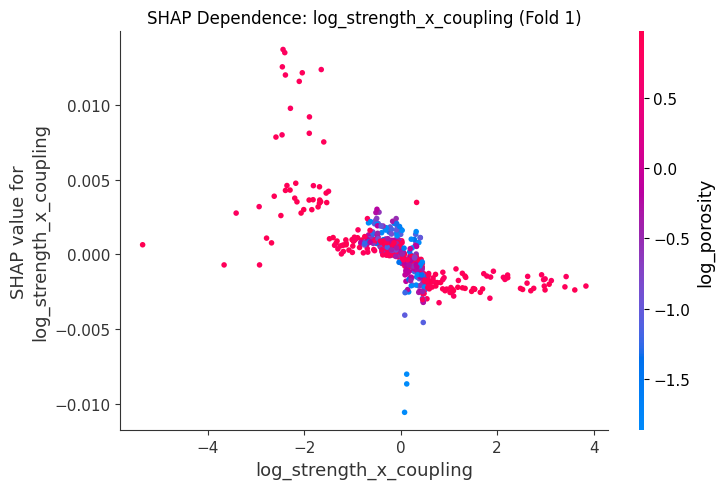

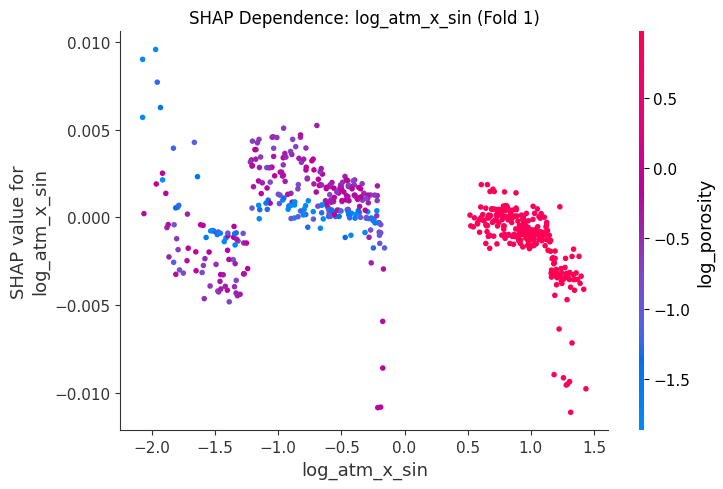

Fold 1 — RMSE=0.0121, MAPE=18.22%, R²=0.9697, F1=0.9822

=== Fold 2 / logit_fines_frac convergence ===
Training until validation scores don't improve for 30 rounds
[10]	valid_residual's l2: 0.0564692	train_residual's l2: 0.0480025
[20]	valid_residual's l2: 0.0566835	train_residual's l2: 0.0442866
[30]	valid_residual's l2: 0.0571762	train_residual's l2: 0.0408655
[40]	valid_residual's l2: 0.0572187	train_residual's l2: 0.0379232
Early stopping, best iteration is:
[11]	valid_residual's l2: 0.0564081	train_residual's l2: 0.0475831
Evaluated only: l2
Fold 2: valid_l2 start=0.0568225, end=0.0572503, best=0.0564081 at iter 11


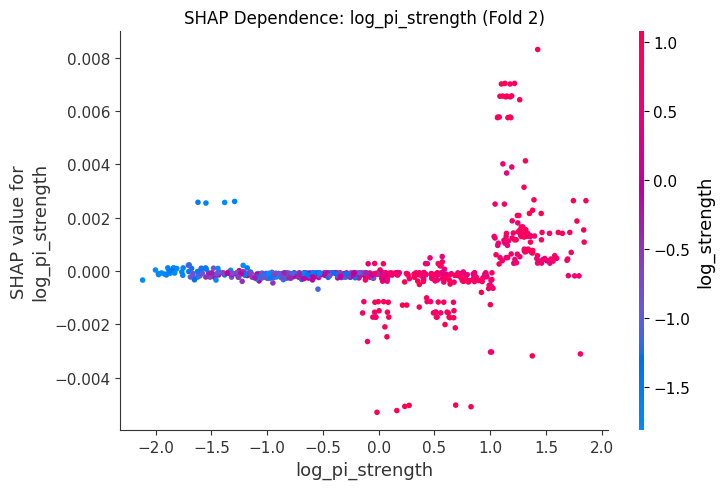

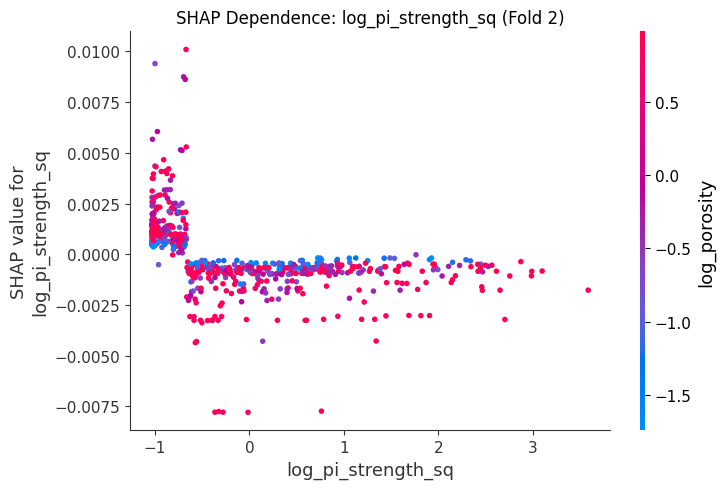

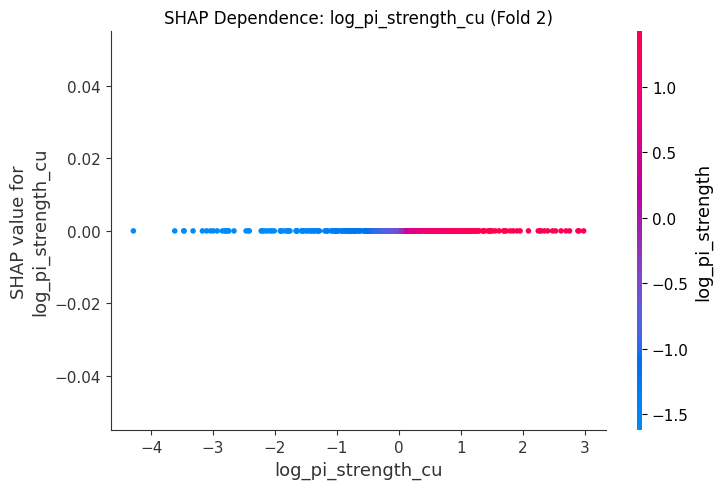

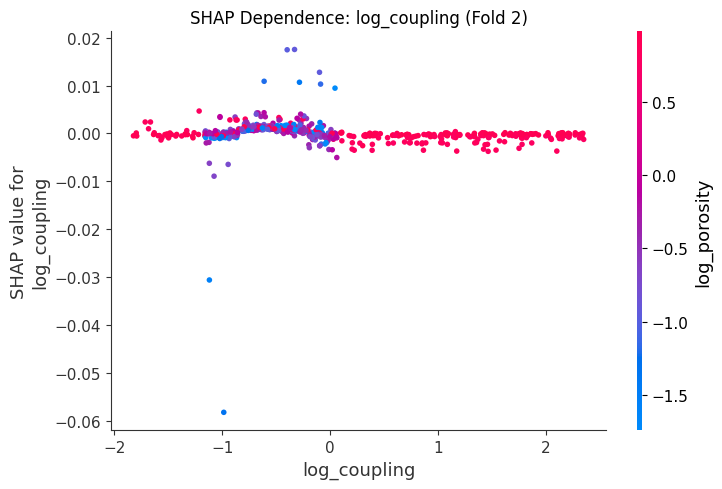

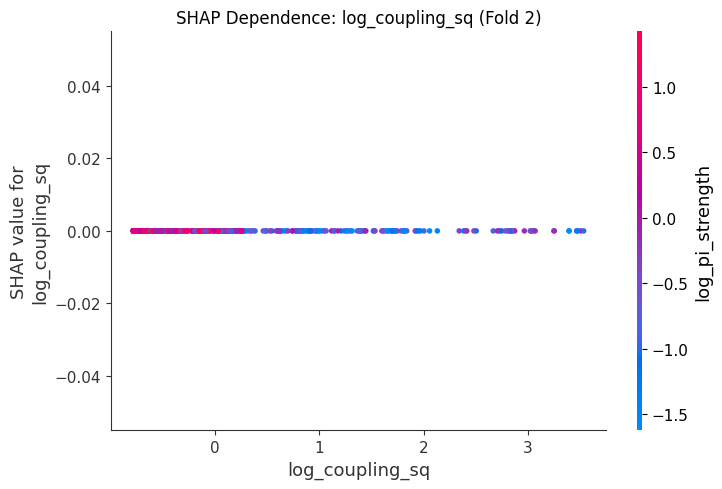

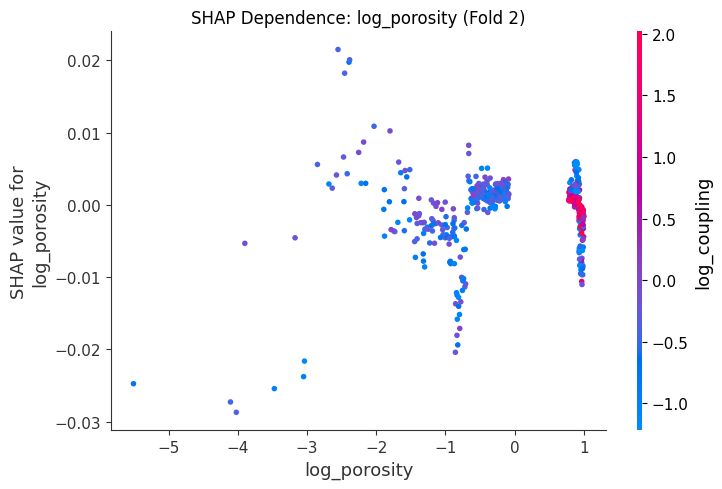

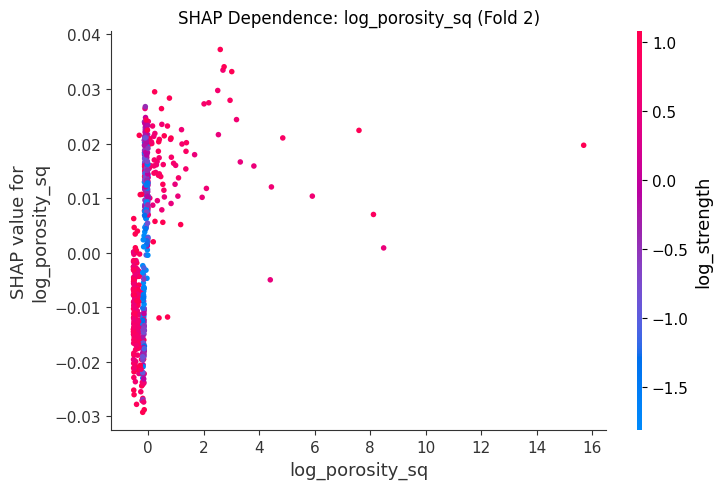

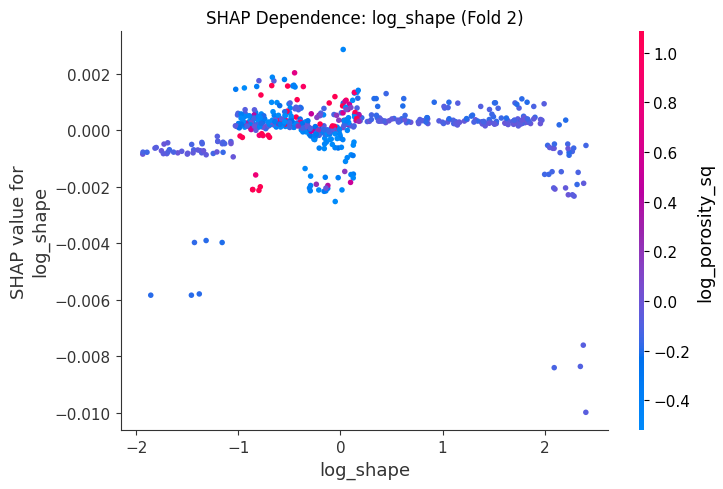

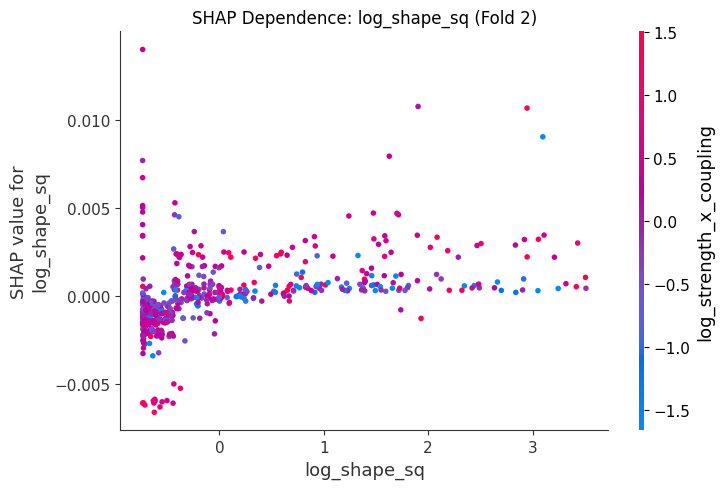

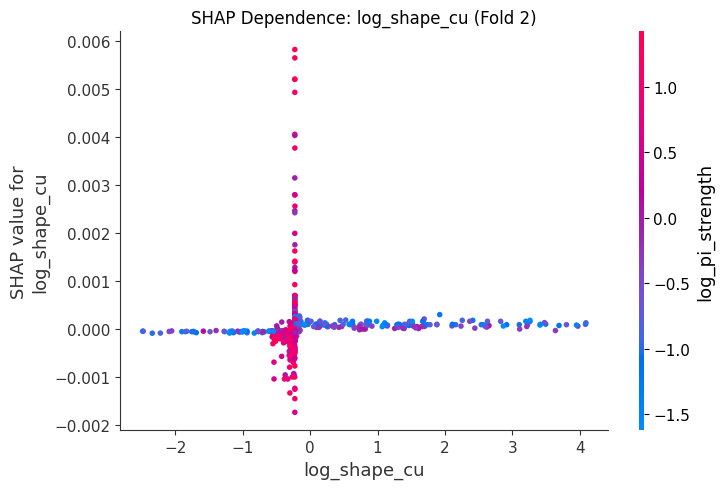

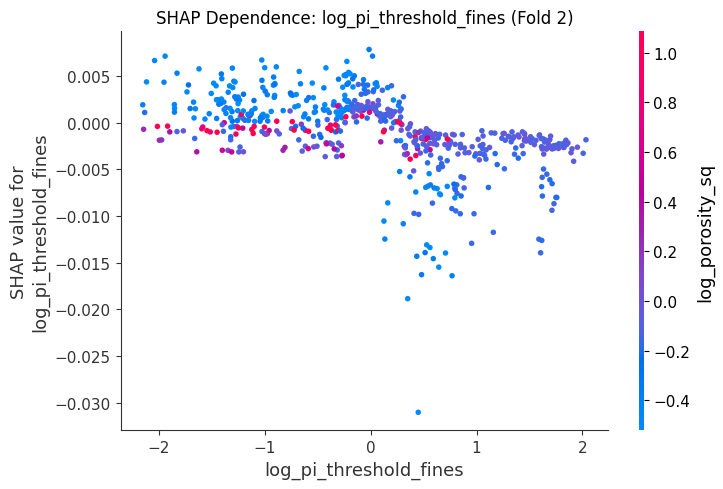

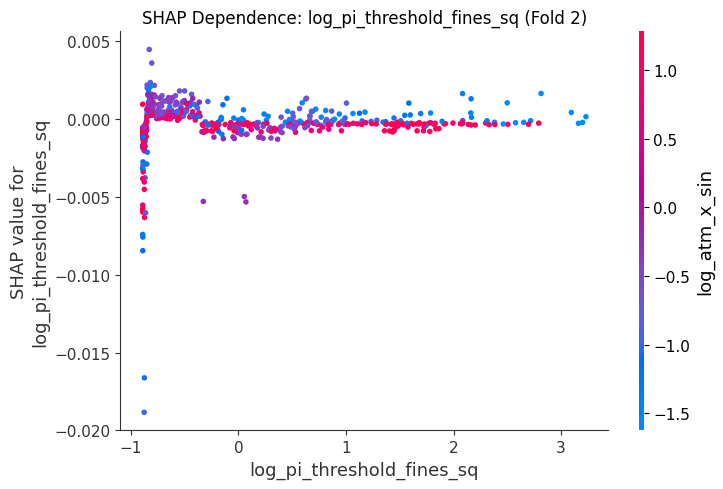

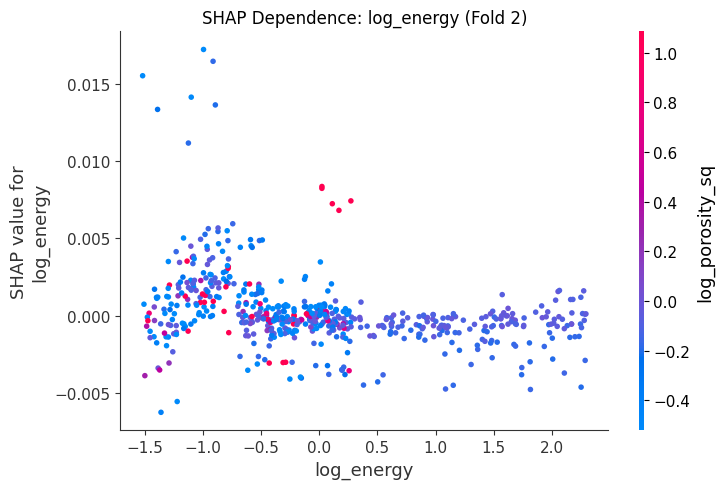

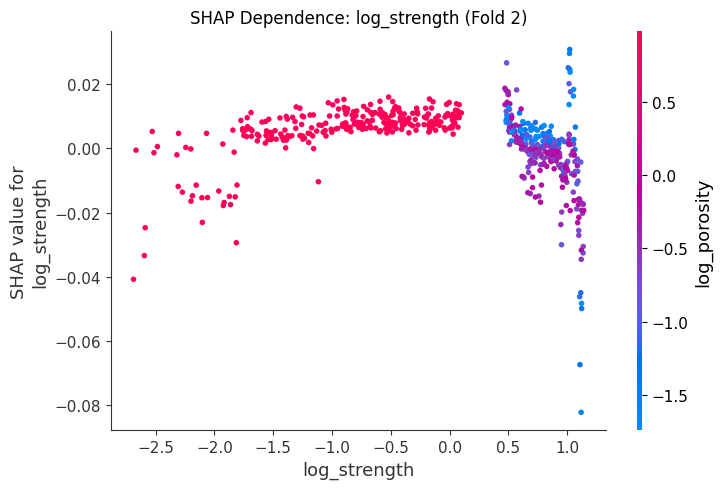

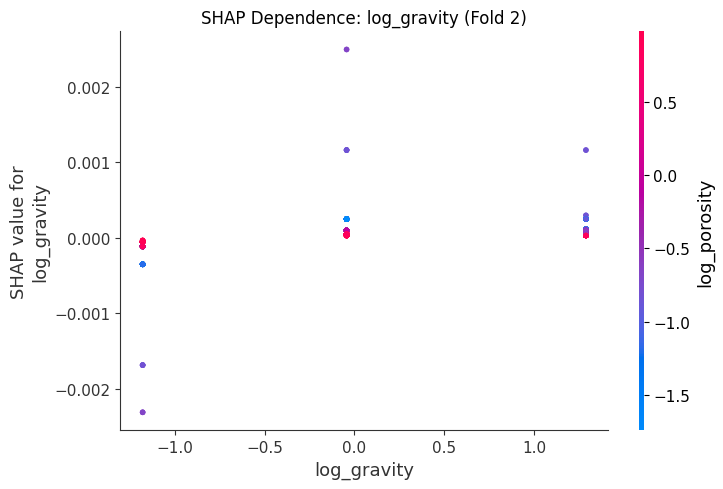

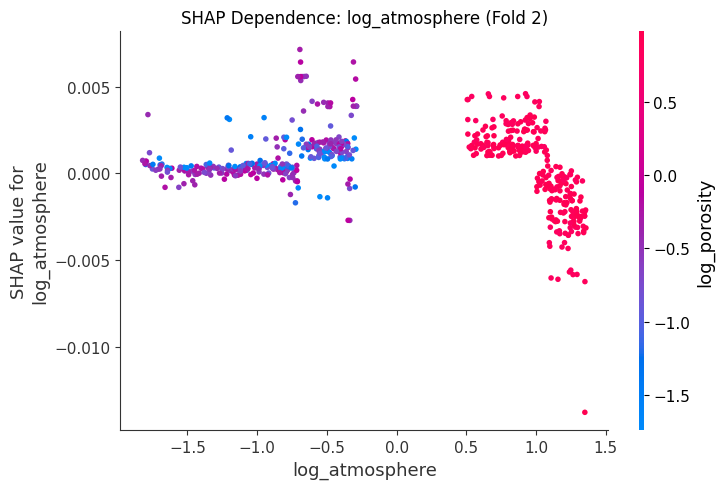

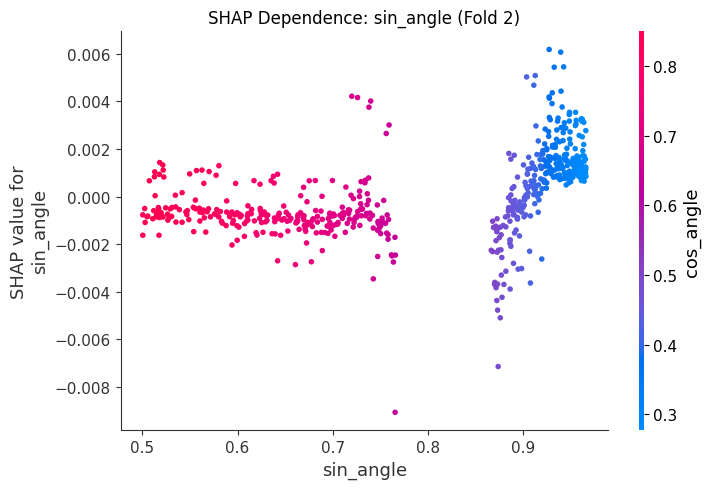

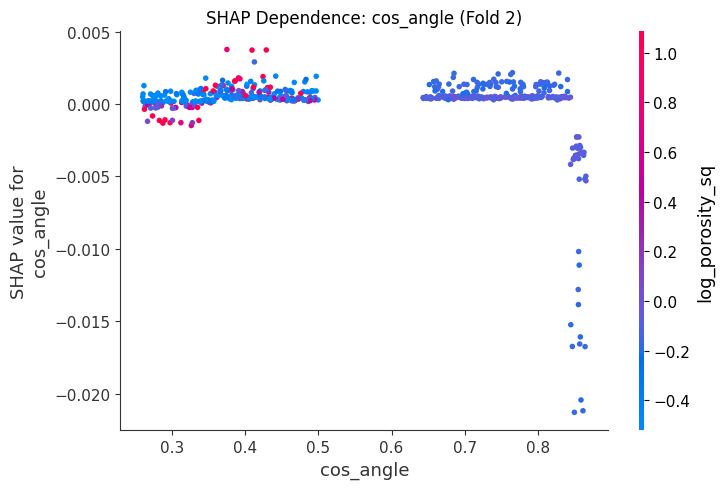

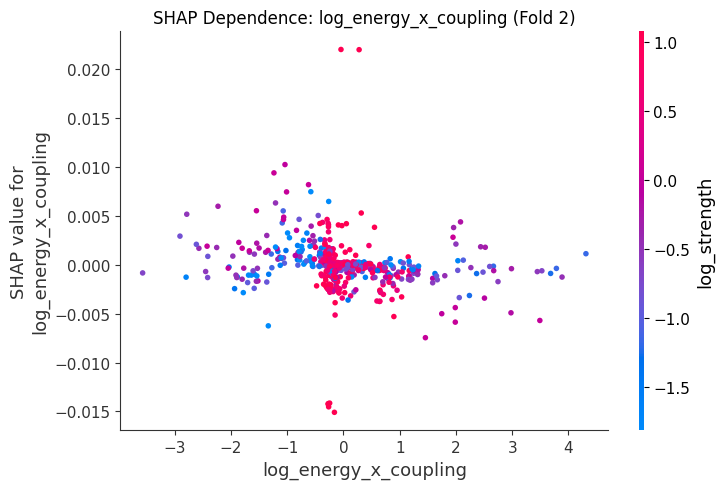

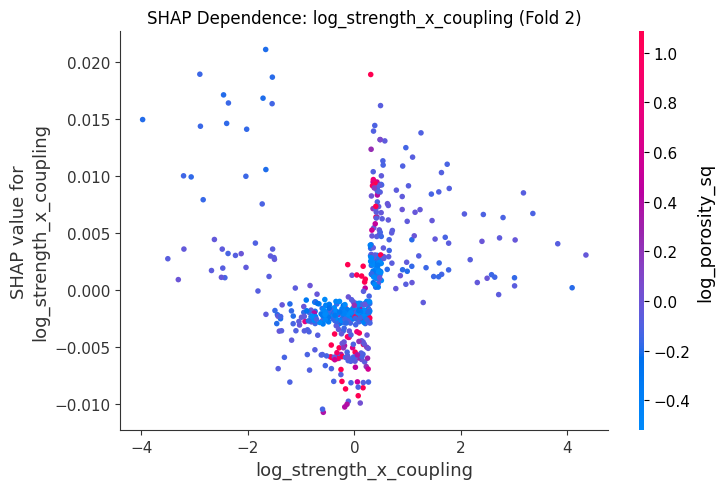

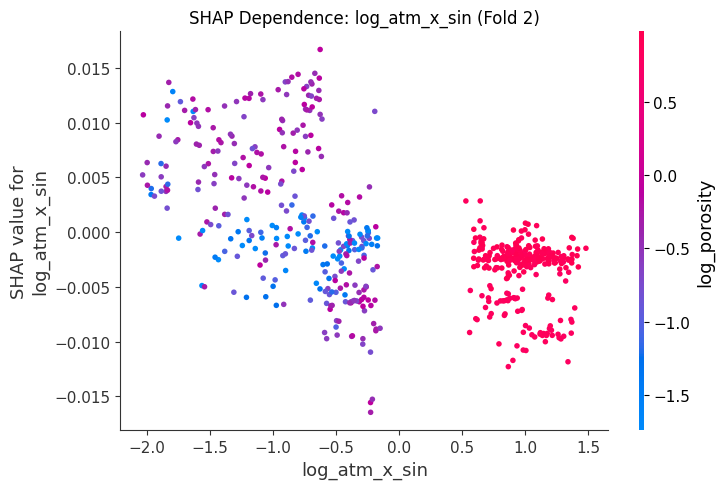

Fold 2 — RMSE=0.0146, MAPE=18.28%, R²=0.9538, F1=0.9761

=== Fold 3 / logit_fines_frac convergence ===
Training until validation scores don't improve for 30 rounds
[10]	valid_residual's l2: 0.050239	train_residual's l2: 0.0494468
[20]	valid_residual's l2: 0.0507037	train_residual's l2: 0.0454149
[30]	valid_residual's l2: 0.050536	train_residual's l2: 0.0420448
Early stopping, best iteration is:
[4]	valid_residual's l2: 0.0501449	train_residual's l2: 0.0525628
Evaluated only: l2
Fold 3: valid_l2 start=0.0503101, end=0.0506076, best=0.0501449 at iter 4


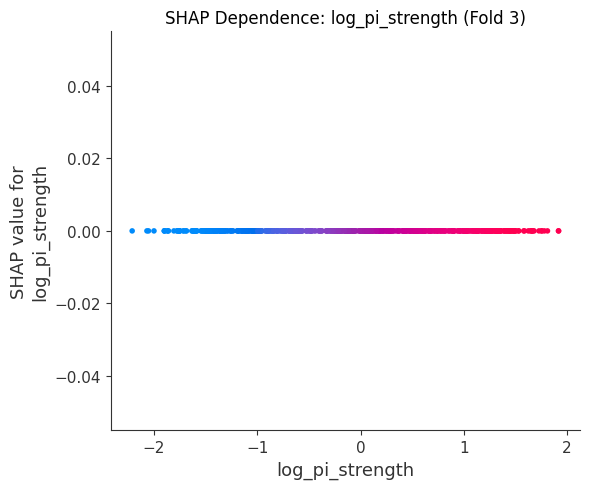

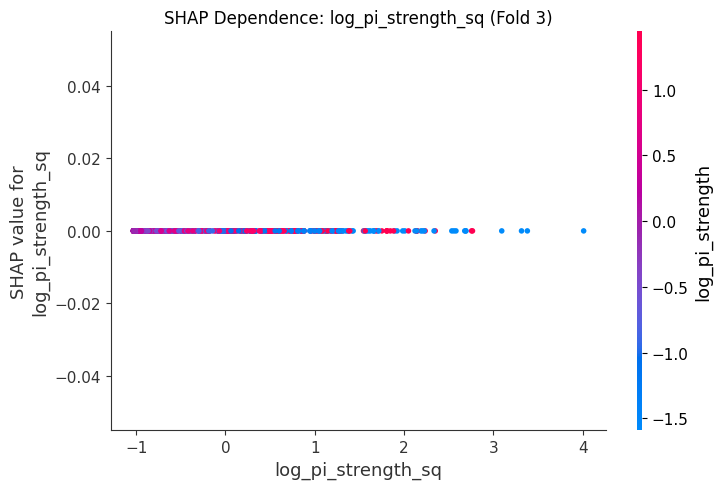

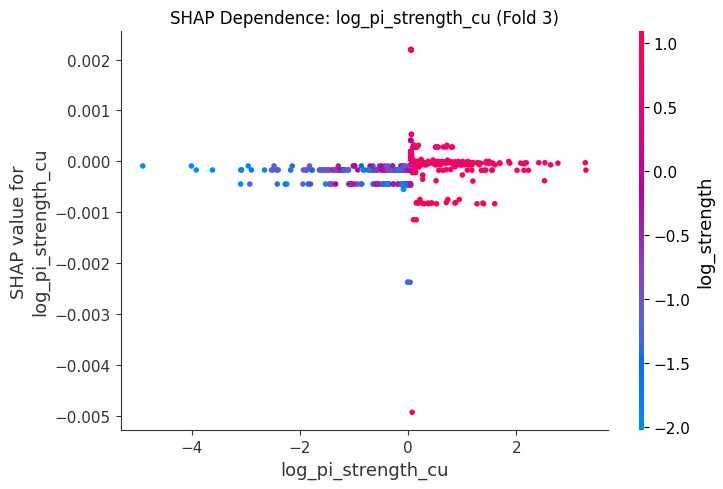

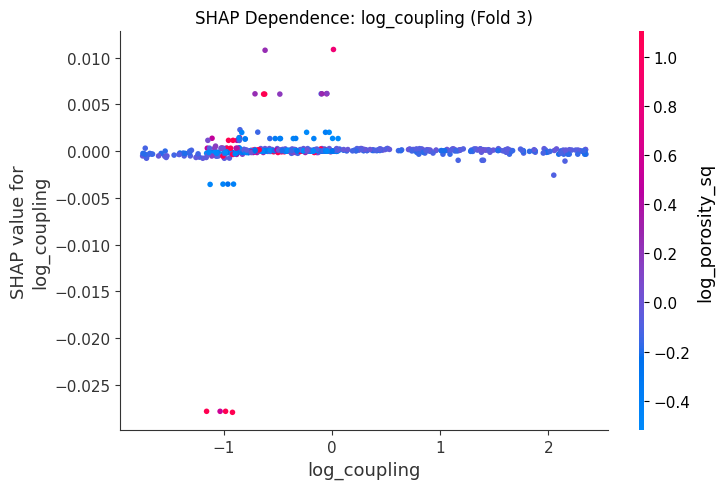

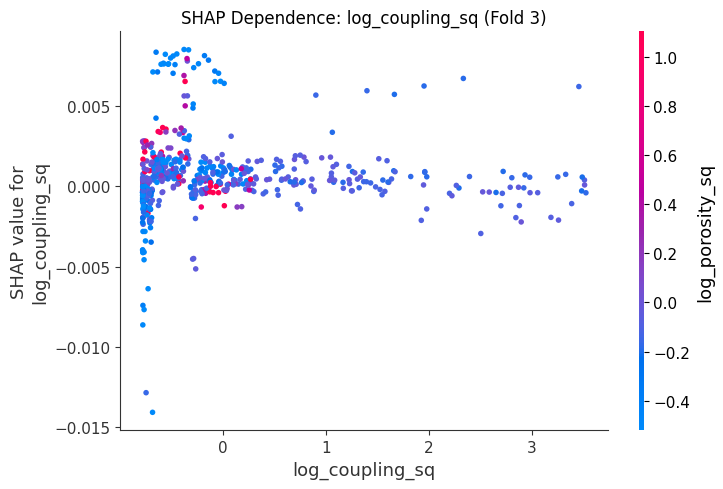

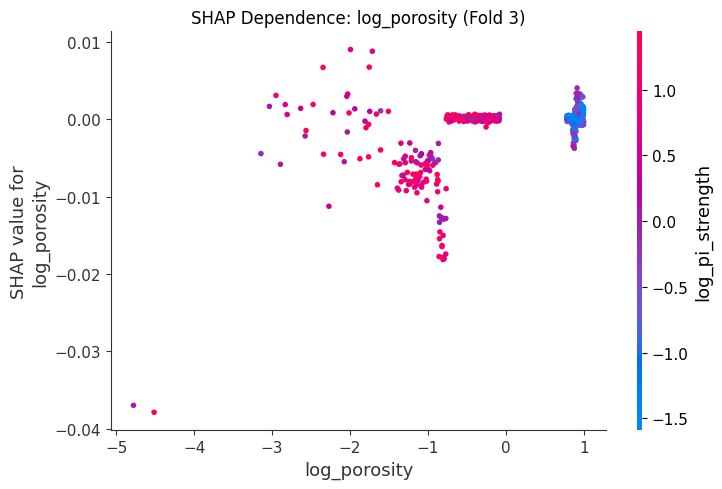

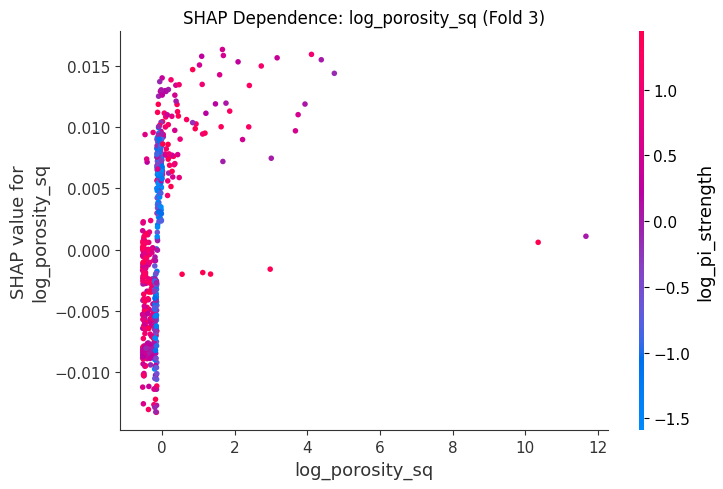

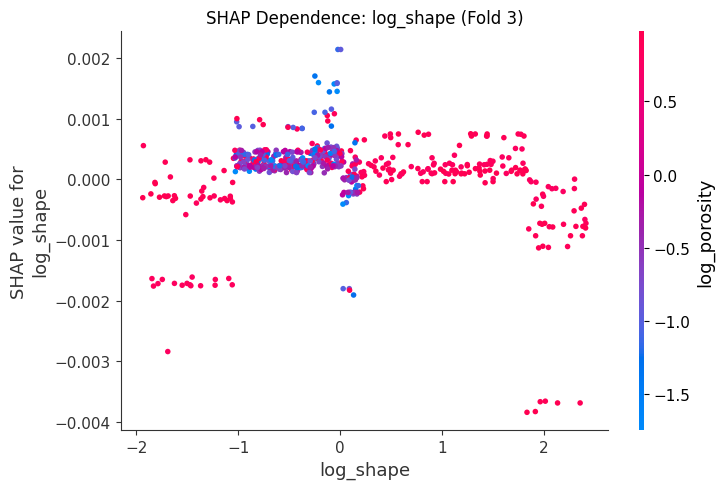

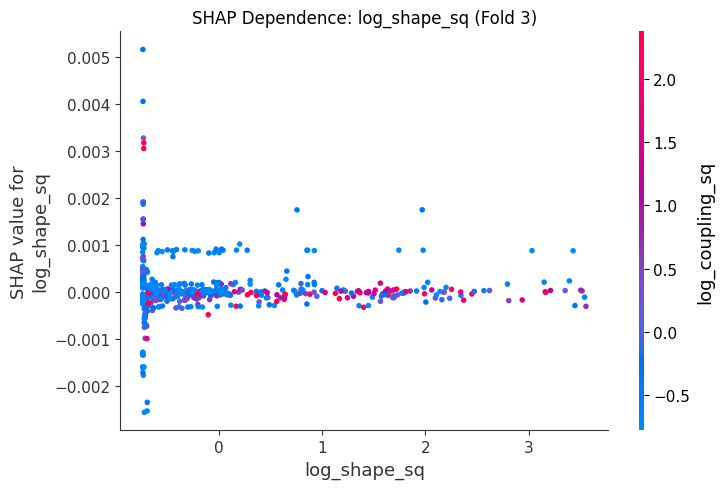

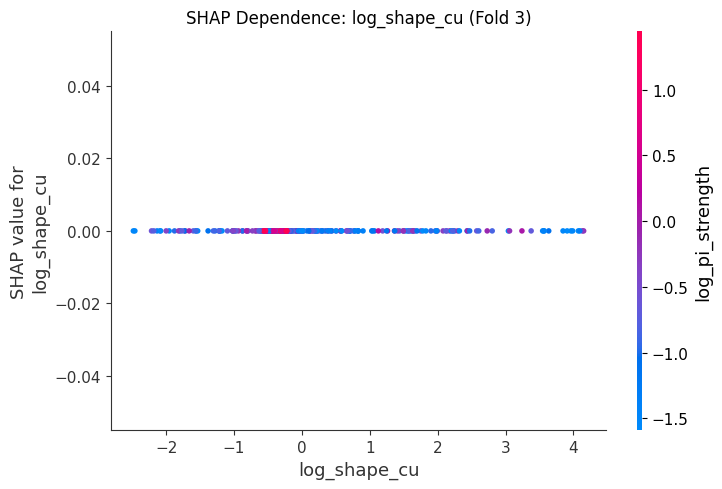

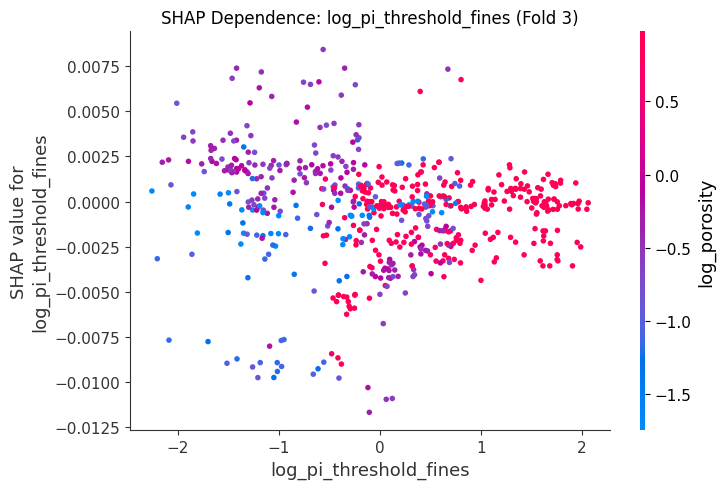

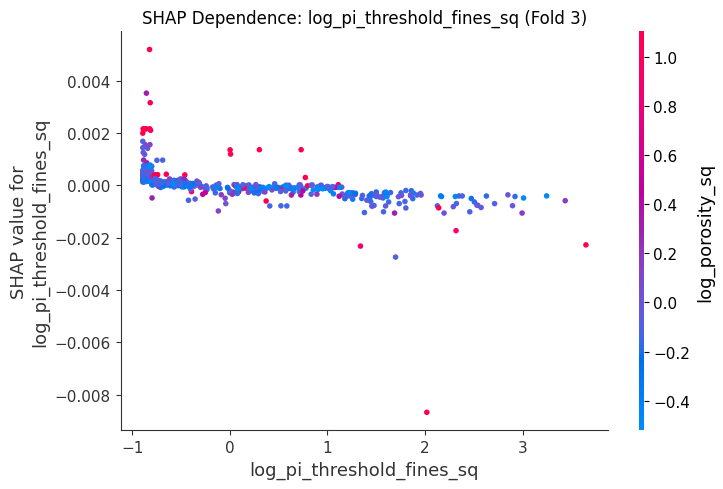

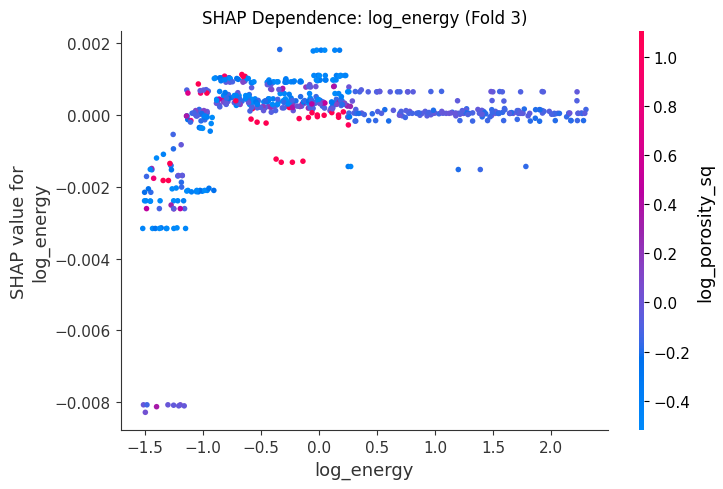

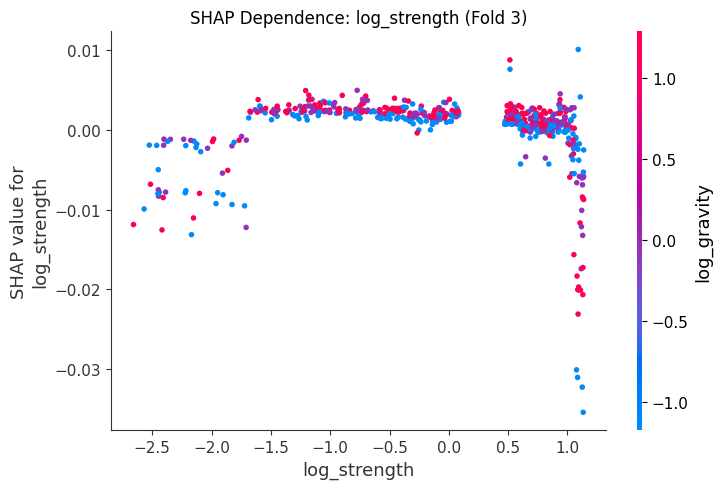

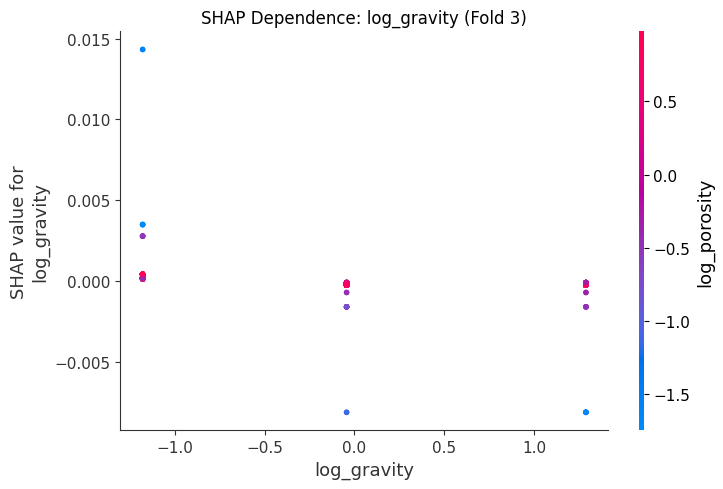

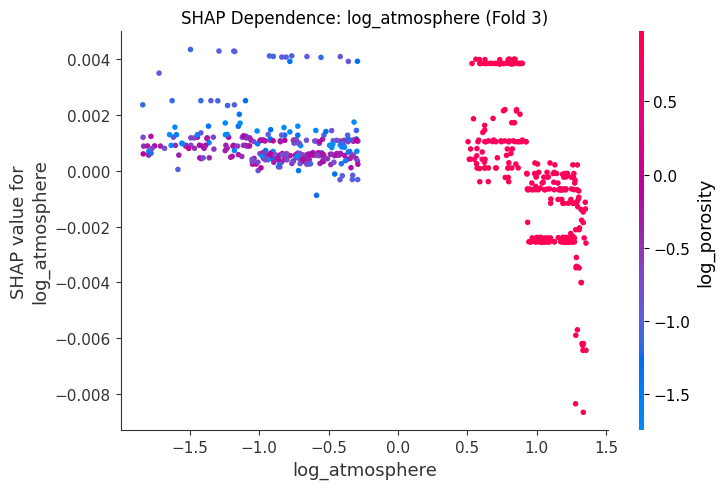

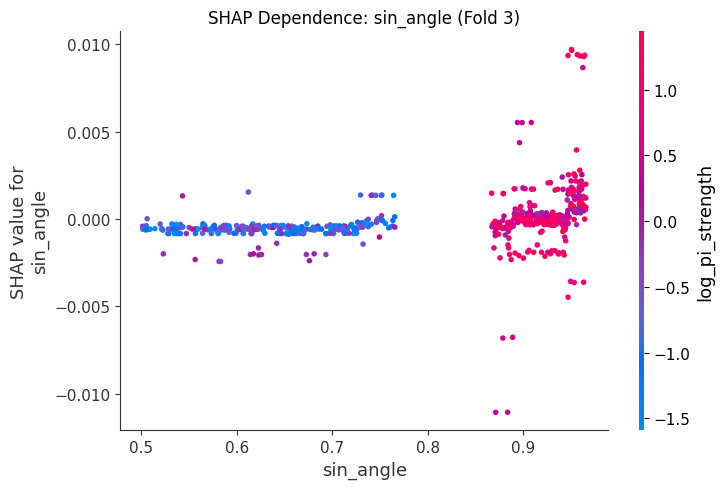

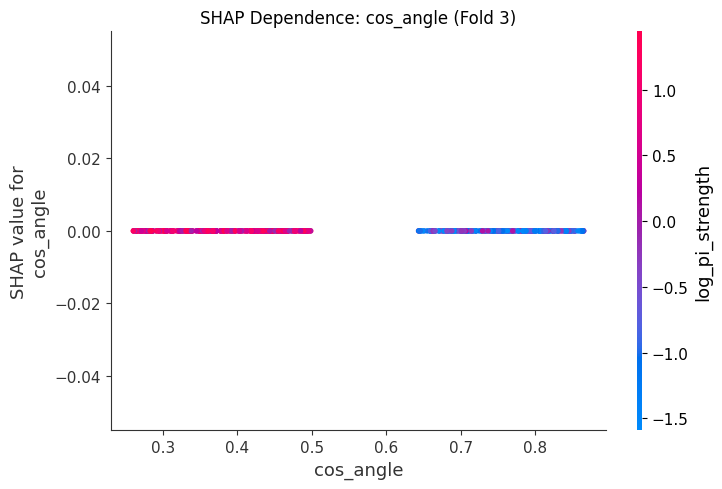

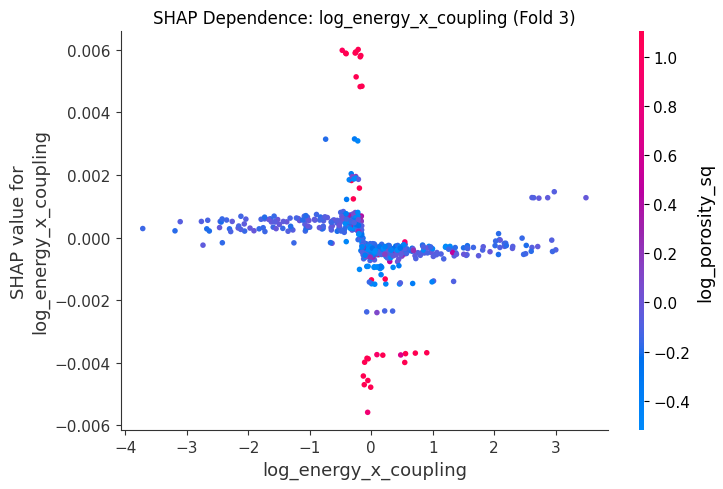

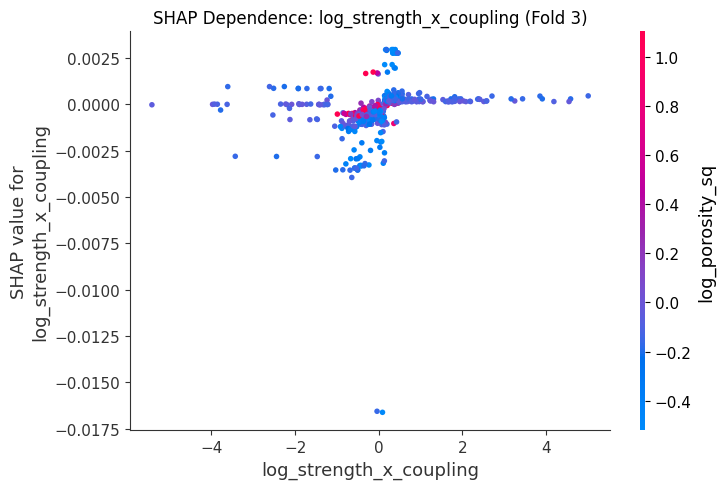

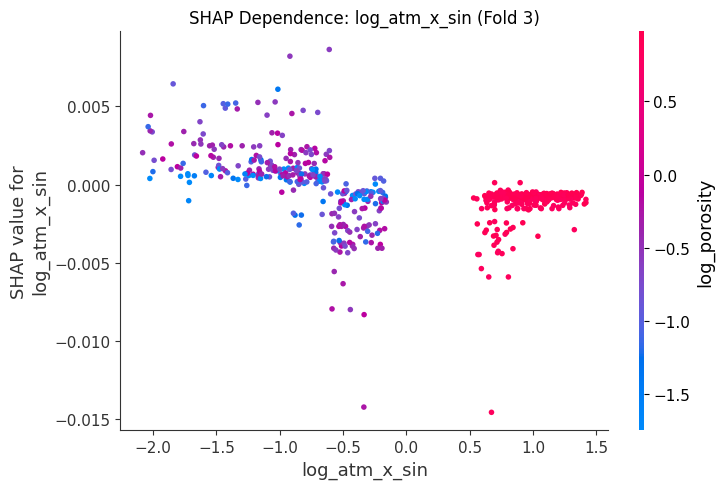

Fold 3 — RMSE=0.0133, MAPE=17.77%, R²=0.9594, F1=0.9732

=== Fold 4 / logit_fines_frac convergence ===
Training until validation scores don't improve for 30 rounds
[10]	valid_residual's l2: 0.0556106	train_residual's l2: 0.0485046
[20]	valid_residual's l2: 0.0554649	train_residual's l2: 0.0448048
[30]	valid_residual's l2: 0.0553901	train_residual's l2: 0.0412374
[40]	valid_residual's l2: 0.0554944	train_residual's l2: 0.0383315
[50]	valid_residual's l2: 0.0556022	train_residual's l2: 0.0358538
Early stopping, best iteration is:
[27]	valid_residual's l2: 0.0552779	train_residual's l2: 0.0423187
Evaluated only: l2
Fold 4: valid_l2 start=0.0565907, end=0.0557271, best=0.0552779 at iter 27


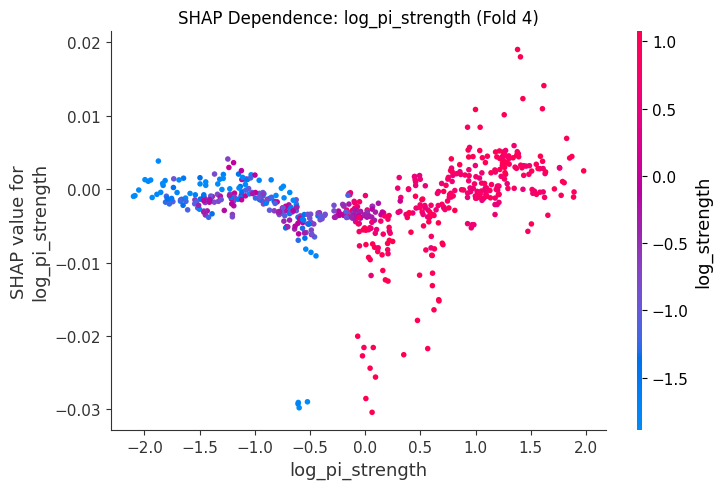

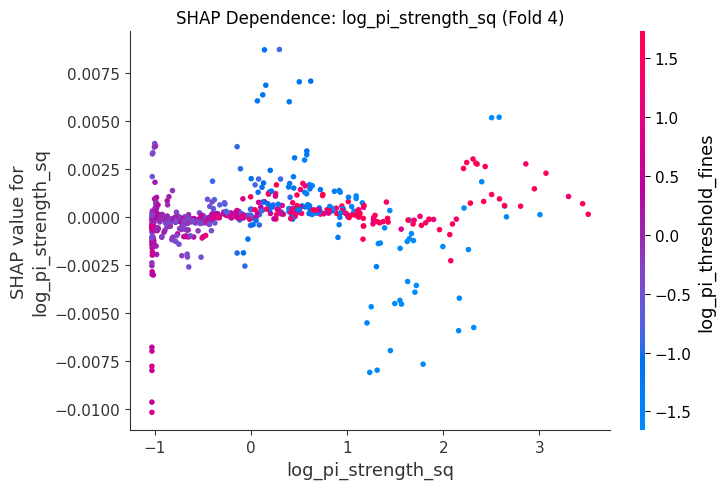

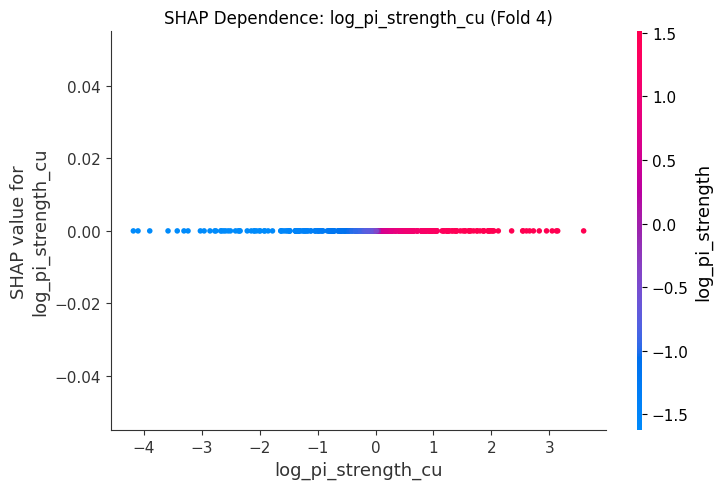

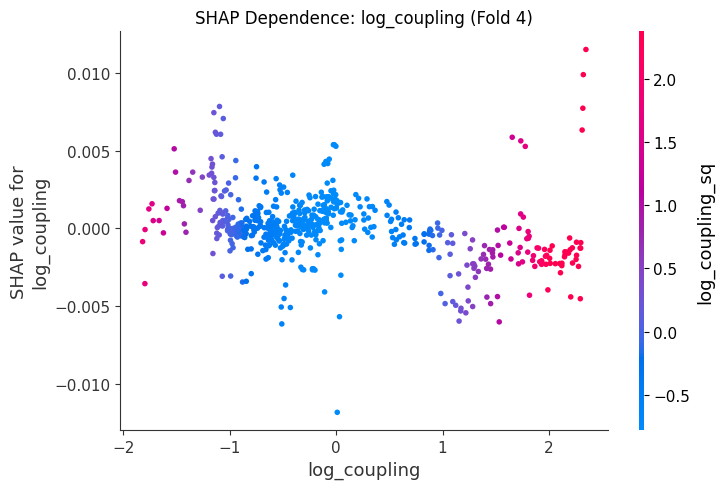

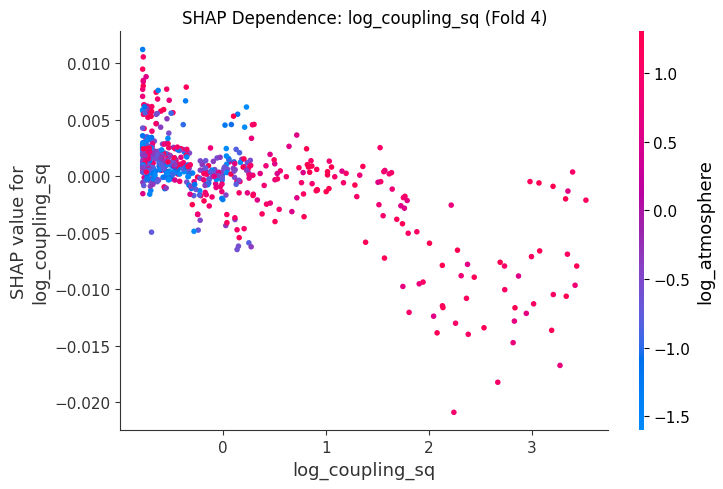

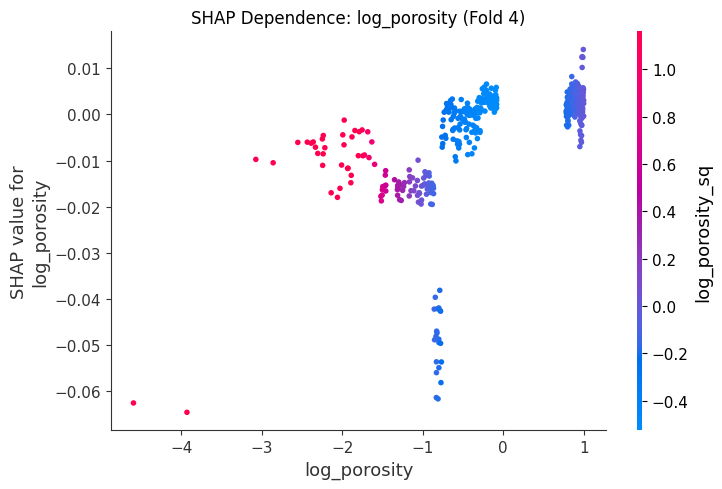

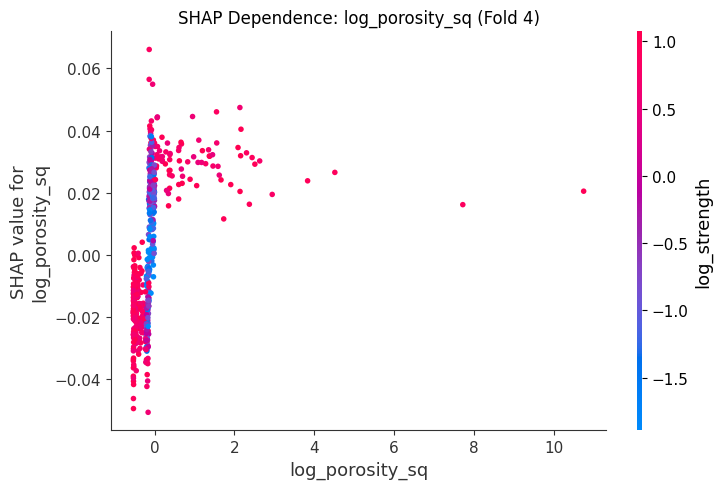

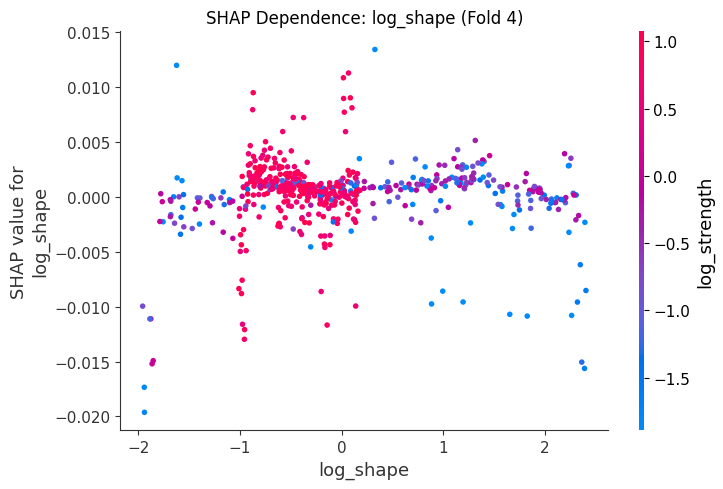

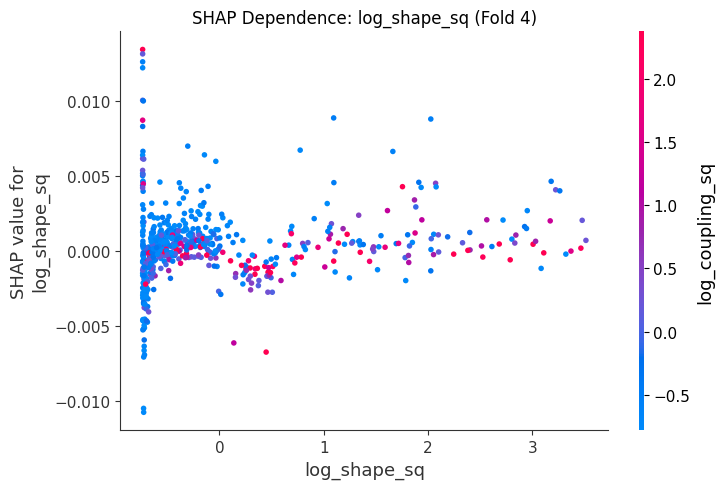

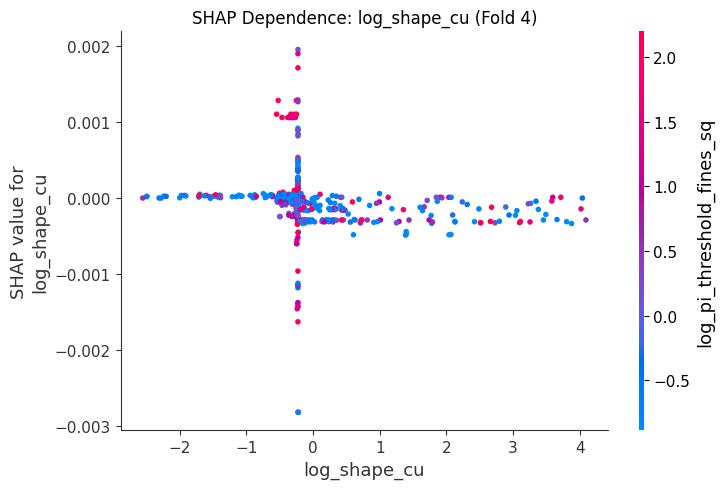

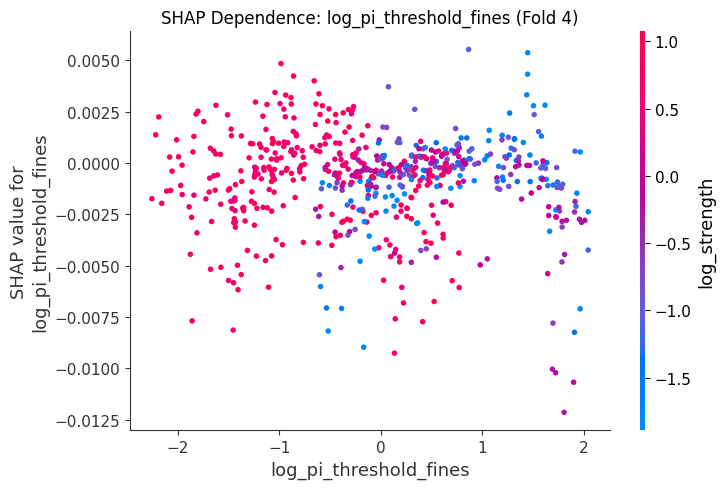

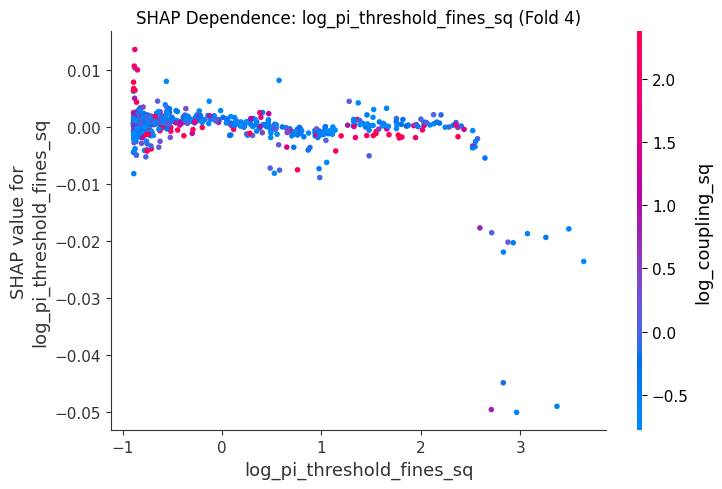

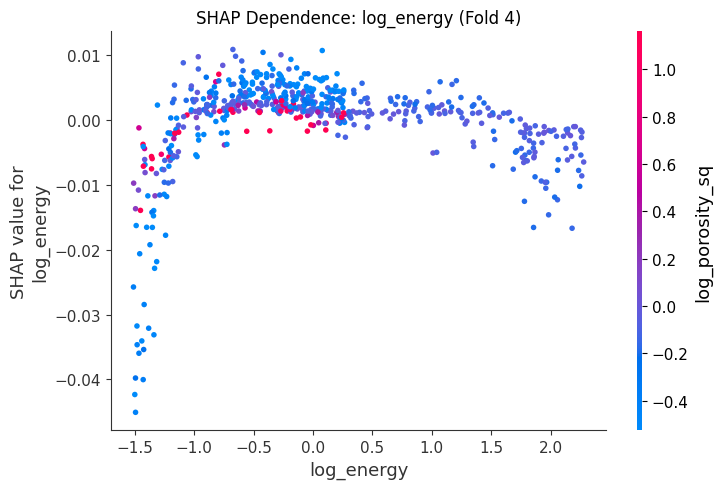

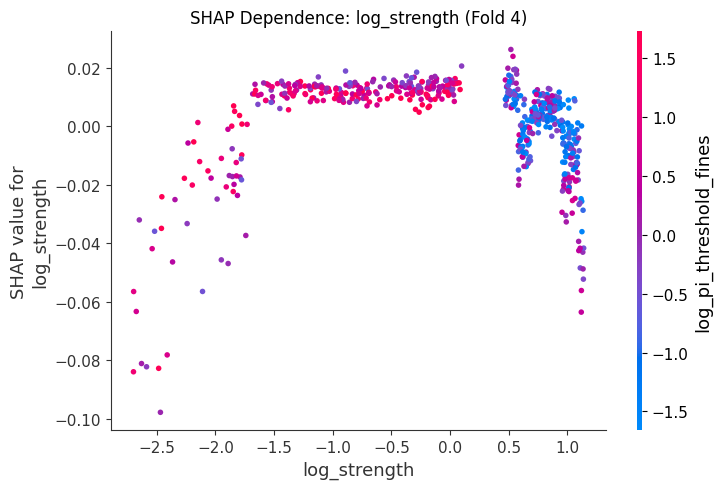

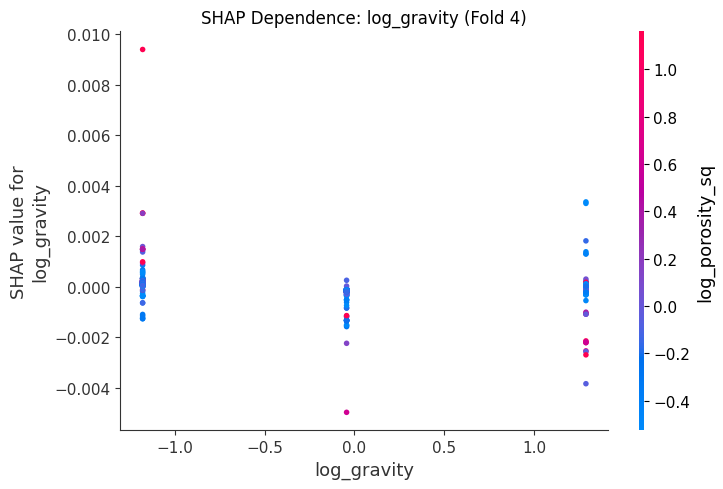

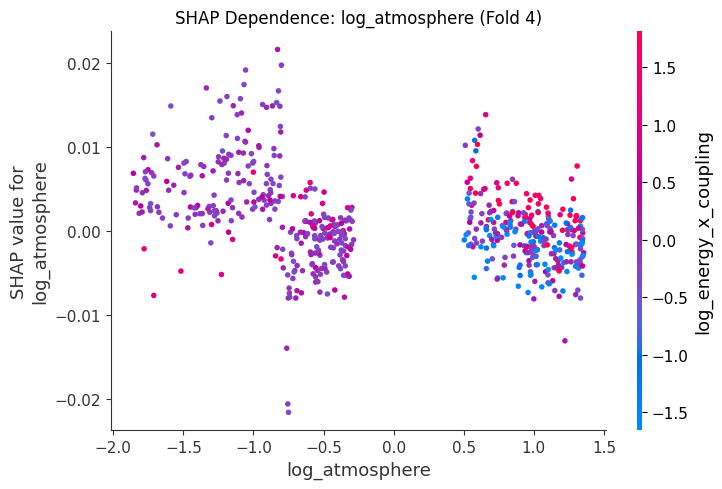

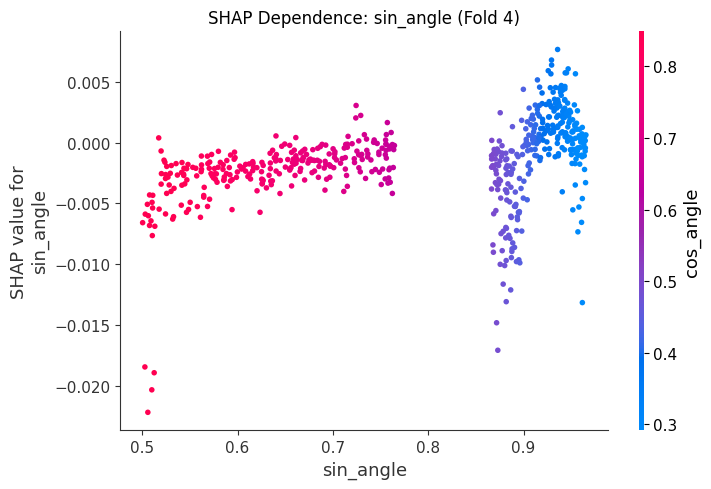

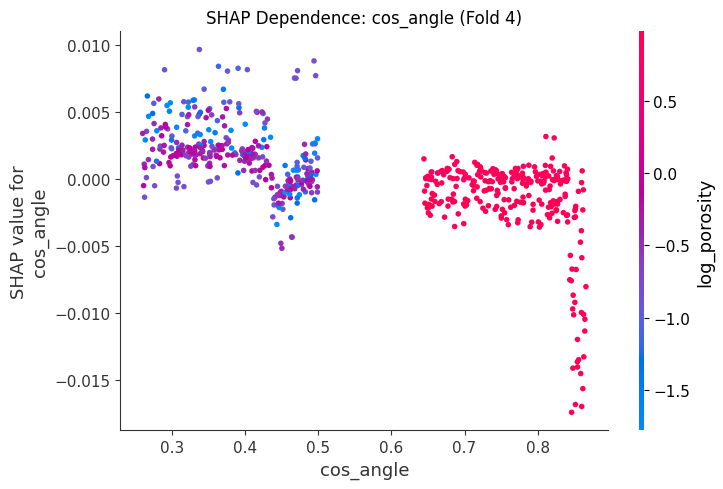

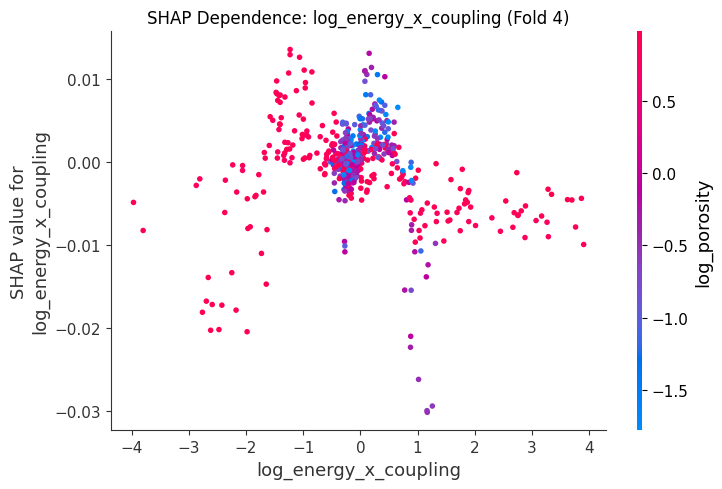

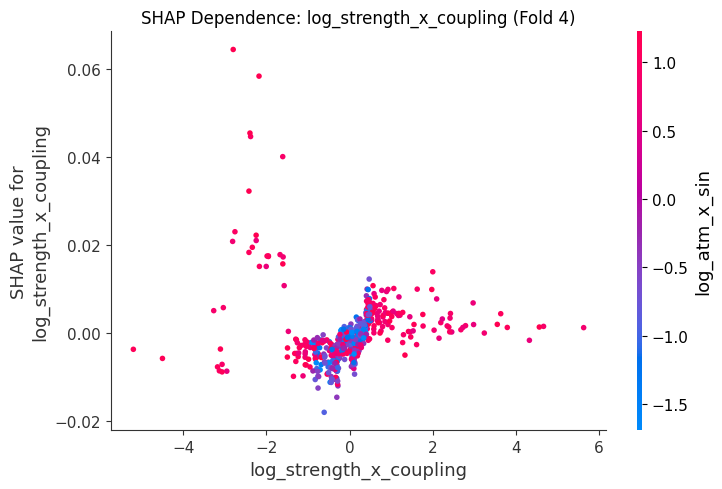

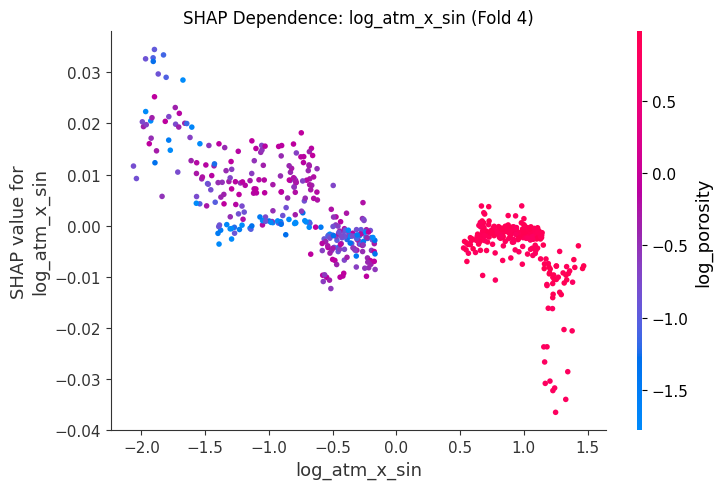

Fold 4 — RMSE=0.0129, MAPE=18.38%, R²=0.9641, F1=0.9711


In [14]:
for fold, (tr, va) in enumerate(kf.split(X)):
    X_tr, X_va = X.iloc[tr], X.iloc[va]
    y_tr, y_va = y.iloc[tr], y.iloc[va]
    y_tr_phys = y_raw["fines_frac"].iloc[tr].reset_index(drop=True)

    print(f"\n=== Fold {fold} / {TARGET} convergence ===")
    model = HybridPhysicsModel(linear_features=LINEAR_FEATURES, lgb_features=LGB_FEATURES)

    model.baseline = Ridge(alpha=model.ridge_alpha).fit(X_tr[model.linear_features], y_tr)
    train_residuals = y_tr - model.baseline.predict(X_tr[model.linear_features])
    valid_residuals = y_va - model.baseline.predict(X_va[model.linear_features])

    evals_result = {}
    model.residual = lgb.LGBMRegressor(**model.lgb_params).fit(
        X_tr[model.lgb_features],
        train_residuals,
        eval_set=[
            (X_va[model.lgb_features], valid_residuals),
            (X_tr[model.lgb_features], train_residuals),
        ],
        eval_names=["valid_residual", "train_residual"],
        eval_metric="l2",
        callbacks=[
            lgb.record_evaluation(evals_result),
            lgb.log_evaluation(period=10),
            lgb.early_stopping(stopping_rounds=early_stopping_rounds, first_metric_only=True),
        ],
    )
    model.best_iteration_ = model.residual.best_iteration_
    convergence_history[fold] = evals_result

    valid_l2 = evals_result["valid_residual"]["l2"]
    best_iter = model.best_iteration_ or (int(np.argmin(valid_l2)) + 1)
    best_iterations.append(best_iter)
    print(
        f"Fold {fold}: valid_l2 start={valid_l2[0]:.6g}, "
        f"end={valid_l2[-1]:.6g}, best={min(valid_l2):.6g} at iter {best_iter}"
    )

    preds_transformed = model.predict(X_va)

    explainer = shap.TreeExplainer(model.residual)
    shap_values = explainer.shap_values(X_va[model.lgb_features])
    shap_history[fold] = {
        "values": shap_values,
        "features": X_va[model.lgb_features].copy(),
        "feature_names": model.lgb_features,
    }

    if plot_shap_dependence:
        for feature_to_plot in model.lgb_features:
            shap.dependence_plot(
                feature_to_plot,
                shap_values,
                X_va[model.lgb_features],
                interaction_index="auto",
                show=False,
            )
            plt.title(f"SHAP Dependence: {feature_to_plot} (Fold {fold})")
            plt.tight_layout()
            plt.show()

    preds_physical = invert_target_fines_frac(pd.Series(preds_transformed, index=X_va.index))
    y_va_phys = y_raw["fines_frac"].iloc[va].reset_index(drop=True)
    preds_physical = preds_physical.reset_index(drop=True)

    y_true = y_va_phys.to_numpy()
    y_pred = preds_physical.to_numpy()
    cv_rmse.append(np.sqrt(mean_squared_error(y_true, y_pred)))
    cv_mape.append(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
    cv_r2.append(r2_score(y_true, y_pred))

    thr = np.median(y_tr_phys)
    y_bin = (y_true > thr).astype(int)
    p_bin = (y_pred > thr).astype(int)
    cv_f1.append(f1_score(y_bin, p_bin, zero_division=0))

    print(f"Fold {fold} — RMSE={cv_rmse[-1]:.4f}, MAPE={cv_mape[-1]:.2f}%, R²={cv_r2[-1]:.4f}, F1={cv_f1[-1]:.4f}")

### SHAP Summary Plot

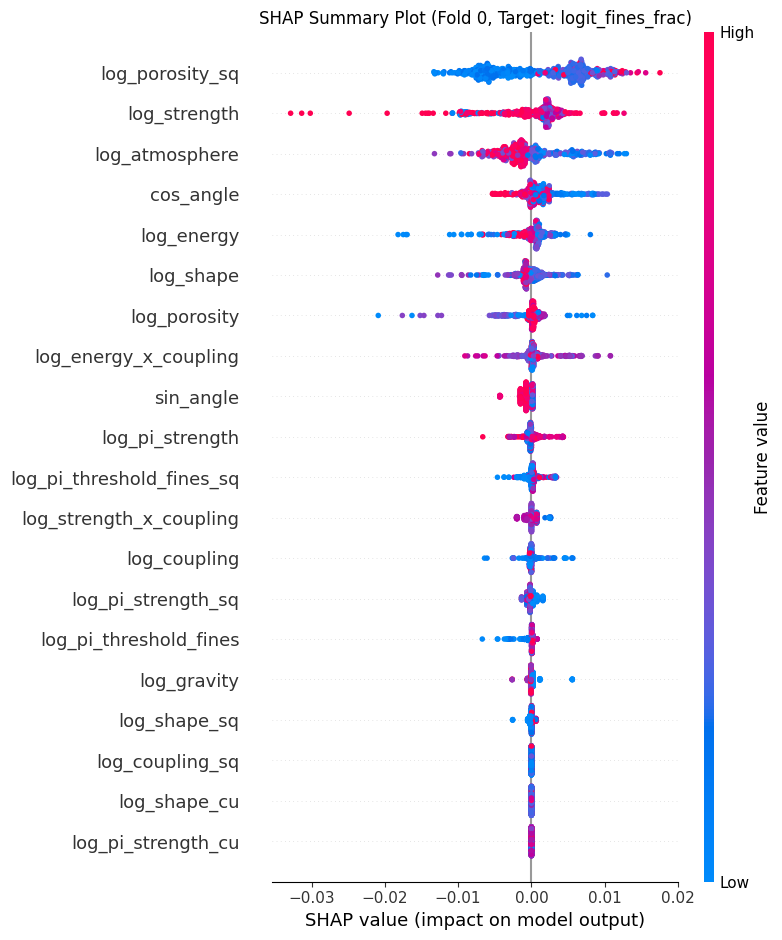

In [15]:
summary_fold = 0
entry = shap_history.get(summary_fold)
if entry is None:
    print(f"No SHAP values found for fold={summary_fold}. Run the CV loop first.")
else:
    shap.summary_plot(entry["values"], entry["features"], show=False)
    plt.title(f"SHAP Summary Plot (Fold {summary_fold}, Target: {TARGET})")
    plt.tight_layout()
    plt.show()

### LightGBM convergence plot

Saved convergence plot


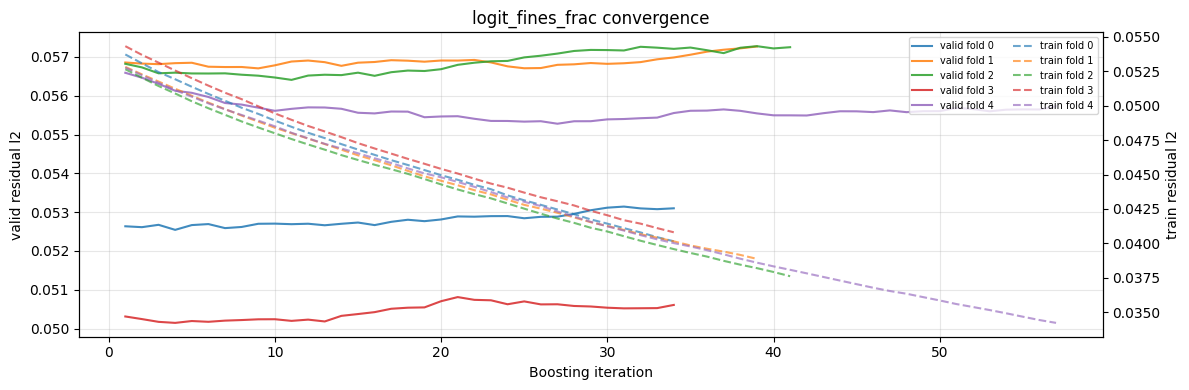

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
train_ax = ax.twinx()
for fold in range(n_splits):
    hist = convergence_history.get(fold)
    if hist is None:
        continue
    train_l2 = hist["train_residual"]["l2"]
    valid_l2 = hist["valid_residual"]["l2"]
    iters = np.arange(1, len(valid_l2) + 1)
    color = f"C{fold}"
    ax.plot(iters, valid_l2, color=color, linestyle="-", alpha=0.85, label=f"valid fold {fold}")
    train_ax.plot(iters, train_l2, color=color, linestyle="--", alpha=0.65, label=f"train fold {fold}")
ax.set_title(f"{TARGET} convergence")
ax.set_ylabel("valid residual l2")
ax.set_xlabel("Boosting iteration")
train_ax.set_ylabel("train residual l2")
ax.grid(True, alpha=0.3)
valid_handles, valid_labels = ax.get_legend_handles_labels()
train_handles, train_labels = train_ax.get_legend_handles_labels()
train_ax.legend(valid_handles + train_handles, valid_labels + train_labels, loc="best", fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig("lgbm_convergence_fines_frac.png", dpi=150)
print("Saved convergence plot")
plt.show()

### Mean CV metrics (physical units)

In [17]:
print(f"Mean CV RMSE:  {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")
print(f"Mean CV MAPE:  {np.mean(cv_mape):.2f}% ± {np.std(cv_mape):.2f}%")
print(f"Mean CV R²:    {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"Mean CV F1:    {np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}")

Mean CV RMSE:  0.0136 ± 0.0011
Mean CV MAPE:  18.07% ± 0.29%
Mean CV R²:    0.9606 ± 0.0057
Mean CV F1:    0.9752 ± 0.0038


### CV metric plot

Saved CV metric plot


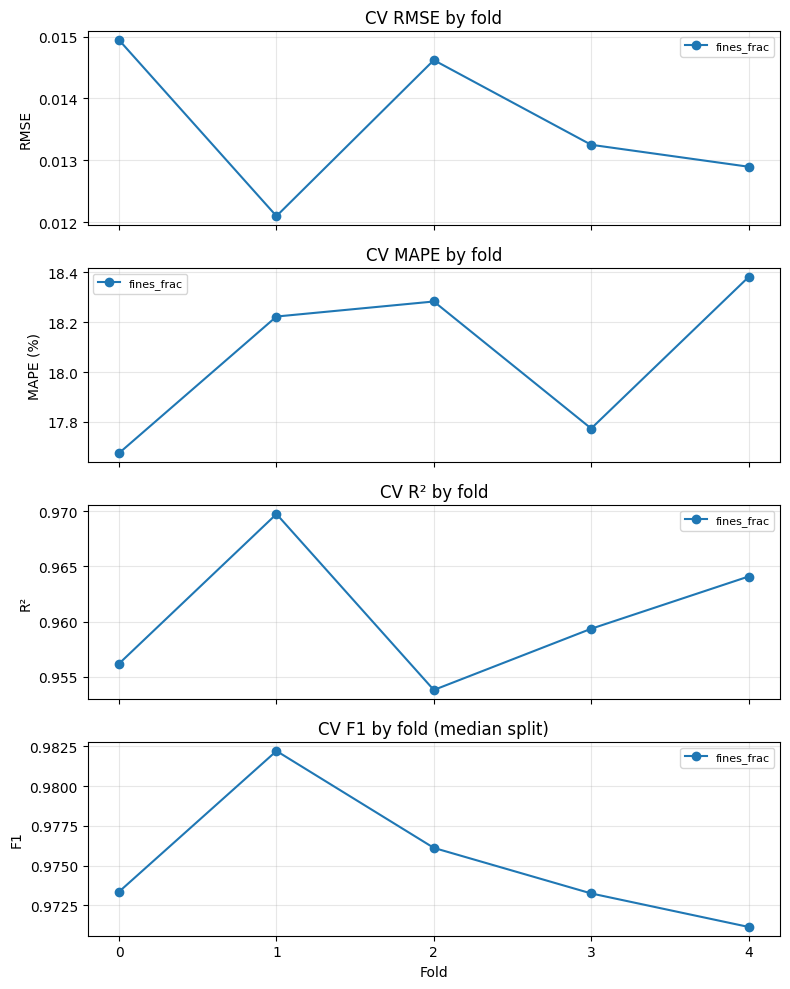

In [18]:
fold_idx = np.arange(n_splits)
fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)
ax_rmse, ax_mape, ax_r2, ax_f1 = axes
ax_rmse.plot(fold_idx, cv_rmse, marker="o", label="fines_frac")
ax_mape.plot(fold_idx, cv_mape, marker="o", label="fines_frac")
ax_r2.plot(fold_idx, cv_r2, marker="o", label="fines_frac")
ax_f1.plot(fold_idx, cv_f1, marker="o", label="fines_frac")
ax_rmse.set_ylabel("RMSE"); ax_rmse.set_title("CV RMSE by fold")
ax_mape.set_ylabel("MAPE (%)"); ax_mape.set_title("CV MAPE by fold")
ax_r2.set_ylabel("R²"); ax_r2.set_title("CV R² by fold")
ax_f1.set_xlabel("Fold"); ax_f1.set_ylabel("F1"); ax_f1.set_title("CV F1 by fold (median split)")
for ax in axes:
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)
ax_f1.set_xticks(fold_idx)
plt.tight_layout()
plt.savefig("cv_metrics_fines_frac.png", dpi=150)
print("Saved CV metric plot")
plt.show()

### Best iterations from early stopping

In [19]:
final_n_estimators = int(np.median(best_iterations))
print(f"{TARGET}: folds={best_iterations}, median_for_final_fit={final_n_estimators}")

logit_fines_frac: folds=[4, 9, 11, 4, 27], median_for_final_fit=9


### Fit final model on full data

In [20]:
final_model = HybridPhysicsModel(
    linear_features=LINEAR_FEATURES,
    lgb_features=LGB_FEATURES,
    lgb_params={
        "n_estimators": final_n_estimators,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_child_samples": 10,
        "reg_alpha": 0.1,
        "reg_lambda": 0.1,
        "verbose": -1,
    },
).fit(X, y)
print(f"\n{TARGET} final n_estimators={final_n_estimators} baseline coefficients:")
print(final_model.baseline_coefficients())


logit_fines_frac final n_estimators=9 baseline coefficients:
log_pi_strength             -0.330907
log_pi_strength_sq          -0.079140
log_pi_strength_cu           0.003522
log_coupling                 0.975046
log_coupling_sq             -0.070485
log_porosity                 0.198120
log_porosity_sq              0.078437
log_shape                   -0.015934
log_shape_sq                 0.003267
log_shape_cu                 0.010434
log_pi_threshold_fines      -0.119604
log_pi_threshold_fines_sq    0.073336
log_energy                   0.414863
log_strength                -1.057152
log_gravity                 -0.074530
log_atmosphere              -0.016767
sin_angle                   -0.015497
cos_angle                    0.197827
log_energy_x_coupling       -0.043123
log_strength_x_coupling      0.106764
log_atm_x_sin               -0.033491
dtype: float64


### Save trained model

In [21]:
joblib.dump(final_model, "model_fines_frac.joblib")

['model_fines_frac.joblib']